In [42]:
# Before anything is pulled I want the plumbing in one place: the libraries, a user agent that
# names this project to the two publishers, the folders the pulls land in, and a display width
# wide enough that the tables this notebook prints do not wrap. The data folder sits one level up
# because it is ignored by git as a whole; everything committed stays inside this project folder.
import hashlib, io, json, re, subprocess, sys, zipfile
from datetime import datetime, timezone
from pathlib import Path
import duckdb, numpy as np, pandas as pd, requests

pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 110)
TIMEOUT = 600
HDRS = {"User-Agent": "data-analytics-portfolio/1.0 (public open data pull)"}
DATA = Path("../data/cimt")
ZIPS, PARQUET, DICT = DATA / "zips", DATA / "parquet", DATA / "dictionary"
for folder in (ZIPS, PARQUET, DICT):
    folder.mkdir(parents=True, exist_ok=True)
print("python", sys.version.split()[0], "| duckdb", duckdb.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)


python 3.14.5 | duckdb 1.5.5 | pandas 3.0.5 | numpy 2.5.2


In [43]:
# Three libraries this project leans on were not in the environment before today and none had
# been tried on this Python version: pyarrow for the Parquet layer, dbt-core with the duckdb
# adapter for the modelling layer, and ruptures for changepoint detection. The first three
# installed; ruptures has no wheel for this interpreter and needs a C++ compiler to build, so the
# changepoint search will be written by hand and named for what it is. This cell records what
# actually loaded, and the dbt path it resolves is the one every later dbt run uses.
import pyarrow, statsmodels
print("pyarrow", pyarrow.__version__, "| statsmodels", statsmodels.__version__)
DBT = str(Path(sys.executable).with_name("dbt"))
dbt_version = subprocess.run([DBT, "--version"], capture_output=True, text=True, encoding="utf-8", errors="replace")
print(" ".join(dbt_version.stdout.split()) or dbt_version.stderr[:300])
try:
    import ruptures
    print("ruptures", ruptures.__version__)
except ImportError as err:
    print("ruptures not installed:", err)


pyarrow 25.0.1 | statsmodels 0.15.0
Core: - installed: 1.12.3 - latest: 1.12.4 - Update available! Your version of dbt-core is out of date! You can find instructions for upgrading here: https://docs.getdbt.com/docs/installation Plugins: - duckdb: 1.11.0 - Up to date!
ruptures not installed: No module named 'ruptures'


In [44]:
# The data is eight packages on open.canada.ca, one per span of years, and every download URL is
# taken from the catalogue's package_show call rather than assumed from a pattern. The handoff I
# am working from listed the seven older packages by the first eight characters of their ids; the
# full ids below came from searching the catalogue on the title. What I want here is one manifest
# of every import zip by year, and a check that every package carries the same three files per
# year so the backfill can treat every year alike.
PACKAGES = [
    "a2b38e8a-b0b0-4163-8426-c4729b0a9689",   # 1988 to 1991
    "6eacb78a-7fb1-49ce-b13c-2a7564092a55",   # 1992 to 1995
    "ed551c1b-ba5d-4391-a08e-8c154fb2e629",   # 1996 to 2001
    "7b9ef472-e806-42f8-8e2a-c8d954e250e0",   # 2002 to 2006
    "d0c43a70-3390-4879-8f1d-b602bb0eba3d",   # 2007 to 2011
    "6f3fd3d9-5a35-47a8-a45a-4b2a8c957453",   # 2012 to 2016
    "b1126a07-fd85-4d56-8395-143aba1747a4",   # 2017 to 2022
    "2909a648-5753-4924-878a-b069392d9cde",   # 2023 to 2026
]
CKAN = "https://open.canada.ca/data/api/action/package_show"
manifest = {"pulled_at_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"), "endpoint": CKAN,
            "packages": [], "imports": []}
for package_id in PACKAGES:
    reply = requests.get(CKAN, params={"id": package_id}, headers=HDRS, timeout=TIMEOUT)
    reply.raise_for_status()
    package = reply.json()["result"]
    csv_resources = [x for x in package["resources"] if x.get("format") == "CSV"]
    kinds = sorted(set(re.sub(r",? ?[0-9]{4}$", "", (x.get("name") or "").strip()) for x in csv_resources))
    years_here = []
    for resource in csv_resources:
        hit = re.search(r"_Imp_([0-9]{4})[.]zip$", resource.get("url") or "")
        if hit:
            years_here.append(int(hit.group(1)))
            manifest["imports"].append({"year": int(hit.group(1)), "url": resource["url"], "resource_id": resource["id"],
                                        "resource_name": (resource.get("name") or "").strip(),
                                        "resource_last_modified": resource.get("last_modified"), "package_id": package_id})
    manifest["packages"].append({"id": package_id, "title": package["title"].strip(), "metadata_modified": package.get("metadata_modified"),
                                 "n_resources": len(package["resources"]), "n_csv": len(csv_resources), "csv_kinds": kinds,
                                 "import_years": sorted(years_here)})
    print(f"{package['title'].strip():<78} resources {len(package['resources']):>2}  csv {len(csv_resources):>2}  "
          f"kinds {kinds}  imports {min(years_here)} to {max(years_here)}")
manifest["imports"].sort(key=lambda entry: entry["year"])
years = [entry["year"] for entry in manifest["imports"]]
print(chr(10) + f"{len(years)} import zips, {years[0]} to {years[-1]}, one per year and contiguous: "
      f"{years == list(range(years[0], years[-1] + 1))}")
Path("python/manifest.json").write_text(json.dumps(manifest, indent=1), encoding="utf-8")
print("written python/manifest.json")


Canadian International Merchandise Trade Web Application (CIMT), 1988-1991     resources 16  csv 12  kinds ['Domestic Exports', 'Imports', 'Total Exports']  imports 1988 to 1991
Canadian International Merchandise Trade Web Application (CIMT), 1992-1995     resources 16  csv 12  kinds ['Domestic Exports', 'Imports', 'Total Exports']  imports 1992 to 1995
Canadian International Merchandise Trade Web Application (CIMT), 1996-2001     resources 22  csv 18  kinds ['Domestic Exports', 'Imports', 'Total Exports']  imports 1996 to 2001
Canadian International Merchandise Trade Web Application (CIMT), 2002-2006     resources 19  csv 15  kinds ['Domestic Exports', 'Imports', 'Total Exports']  imports 2002 to 2006
Canadian International Merchandise Trade Web Application (CIMT), 2007-2011     resources 19  csv 15  kinds ['Domestic Exports', 'Imports', 'Total Exports']  imports 2007 to 2011
Canadian International Merchandise Trade Web Application (CIMT), 2012-2016     resources 19  csv 15  kinds ['D

In [45]:
# One zip before the rest, to see what is inside and pick the file that carries the grain I need.
# I take the most recent year rather than any other because each zip ships the code dictionary as
# it stood when that zip was built, and only the newest snapshot can describe codes introduced
# this year. The download is checked on its content type and its first four bytes before anything
# is written, since a publisher can answer a missing file with an HTML page and a 200 status, and
# the hash is kept so a later re-pull can be compared with this one.
ZIP_MAGIC = bytes([0x50, 0x4B, 0x03, 0x04])
PROBE_YEAR = max(entry["year"] for entry in manifest["imports"])
probe_entry = [entry for entry in manifest["imports"] if entry["year"] == PROBE_YEAR][0]
probe_zip = ZIPS / Path(probe_entry["url"]).name

def fetch_zip(url, target):
    reply = requests.get(url, headers=HDRS, timeout=TIMEOUT, stream=True)
    reply.raise_for_status()
    content_type = (reply.headers.get("content-type") or "").lower()
    chunks = reply.iter_content(1 << 20)
    first = next(chunks, bytes())
    if "zip" not in content_type or not first.startswith(ZIP_MAGIC):
        raise ValueError(f"{url}: not a zip (content type {content_type!r}, first bytes {first[:4]!r})")
    digest = hashlib.sha256(first)
    with open(target, "wb") as out:
        out.write(first)
        for chunk in chunks:
            digest.update(chunk)
            out.write(chunk)
    return {"url": url, "pulled_at_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
            "content_type": content_type, "last_modified": reply.headers.get("last-modified"),
            "bytes": target.stat().st_size, "sha256": digest.hexdigest()}

if probe_zip.exists() and zipfile.is_zipfile(probe_zip):
    print(f"{probe_zip.name} already on disk, {probe_zip.stat().st_size:,} bytes, not downloaded again")
else:
    print(json.dumps(fetch_zip(probe_entry["url"], probe_zip), indent=1))
with zipfile.ZipFile(probe_zip) as archive:
    for info in archive.infolist():
        if not info.is_dir():
            print(f"{info.file_size:>13,}  {info.filename}")


CIMT-CICM_Imp_2026.zip already on disk, 47,894,022 bytes, not downloaded again
       15,882  CIMT-CICM_Imp_2026/Note to User.docx
       14,134  CIMT-CICM_Imp_2026/Note aux utilisateurs.docx
    9,876,107  CIMT-CICM_Imp_2026/ODPFN022_202607N.csv
   11,517,550  CIMT-CICM_Imp_2026/ODPF_1_HS10Desc.TXT
    1,957,575  CIMT-CICM_Imp_2026/ODPF_3_HS6MDesc.TXT
       43,255  CIMT-CICM_Imp_2026/ODPF_5_HS2Desc.TXT
       58,869  CIMT-CICM_Imp_2026/ODPF_6_CtyDesc.TXT
       11,605  CIMT-CICM_Imp_2026/ODPF_7_StateDesc.TXT
        3,376  CIMT-CICM_Imp_2026/ODPF_8_ProvDesc.TXT
       14,981  CIMT-CICM_Imp_2026/ODPF_9_UOMDesc.TXT
  169,916,476  CIMT-CICM_Imp_2026/ODPFN014_202607N.csv
  110,541,945  CIMT-CICM_Imp_2026/ODPFN015_202607N.csv


In [46]:
# The zip holds a note to users, three data files and seven lookup files. The note turns out to
# describe the classification rather than the record layout, so the layout is the header row of
# each data file, printed here with its first two rows. The HS10 file is the one this project
# needs: ten-digit codes by month, partner country, province of clearance and US state. The six
# and two digit files are roll-ups of it, and the state column is blank wherever the partner is
# not the United States.
import docx
with zipfile.ZipFile(probe_zip) as archive:
    note = [name for name in archive.namelist() if name.endswith("Note to User.docx")][0]
    for paragraph in docx.Document(io.BytesIO(archive.read(note))).paragraphs:
        if paragraph.text.strip():
            print(paragraph.text.strip())
            print()
    for name in sorted(name for name in archive.namelist() if "ODPFN" in name):
        with archive.open(name) as member:
            print("==", Path(name).name)
            for _ in range(3):
                print("  ", member.readline().decode("utf-8").rstrip())
DATA_MEMBER = re.compile(r"ODPFN014_[0-9]{6}[A-Z][.]csv$")
DICT_MEMBER = re.compile(r"ODPF_1_HS10Desc[.](txt|TXT)$")
print(chr(10) + "file used from here on: the ODPFN014 member, HS10 by month, partner country, province of clearance and US state")


Note to User

The Canadian International Merchandise Trade (CIMT) Web Application offers detailed trade data using the Harmonized Commodity Description and Coding System (HS) classification of goods. The HS is an international commodity classification system made up of 6 digits (HS-06). The official interpretation of HS is given in the Explanatory Notes (5 volumes in English and French) published by the World Customs Organization. The HS is used by more than 167 countries or economic unions to classify more than 95% of total world trade. In Canada, the international 6-digit root was extended to 8 digits for exports and 10 digits for imports.  The export and import statistics used in the CIMT Web Application are at the level HS-02, HS-06 and HS-08 for exports and HS-02, HS-06 and HS-10 for imports

Revisions to HS codes at the 8th or 10th digit level may happen throughout the year and they usually comprise a minimal number of description changes, additions and deletions. The changes at 

In [47]:
# The HS10 dictionary is the file this project turns on, and the handoff warned it is fixed width,
# not delimited: a CSV reader takes its first line as a header and misparses everything after.
# Before writing a parser I want to see the file: its first lines under a character ruler, the set
# of line lengths, and the column positions where every line holds a space, which is where the
# field boundaries show themselves. The bytes are not UTF-8, so the decode is tried in order and
# the one that works is reported along with the hash of this snapshot of the file.
with zipfile.ZipFile(probe_zip) as archive:
    dict_member = [name for name in archive.namelist() if DICT_MEMBER.search(name)][0]
    dict_bytes = archive.read(dict_member)
for encoding in ("utf-8", "cp1252"):
    try:
        dict_text = dict_bytes.decode(encoding)
        break
    except UnicodeDecodeError as err:
        print(f"not {encoding}: {str(err)[:80]}")
print(f"{Path(dict_member).name}: decoded as {encoding}, {len(dict_bytes):,} bytes, sha256 {hashlib.sha256(dict_bytes).hexdigest()[:16]}")
dict_lines = [line.rstrip(chr(13)) for line in dict_text.split(chr(10)) if line.strip()]
line_lengths = pd.Series([len(line) for line in dict_lines]).value_counts().to_dict()
width = max(line_lengths)
print(f"{len(dict_lines):,} lines; line lengths and counts: {line_lengths}")
print("".join(str((i // 100) % 10) for i in range(width)))
print("".join(str((i // 10) % 10) for i in range(width)))
print("".join(str(i % 10) for i in range(width)))
for line in dict_lines[:10]:
    print(line)
space_count = np.zeros(width, dtype=int)
for line in dict_lines:
    space_count += np.frombuffer(line.encode("latin-1", "replace"), dtype=np.uint8) == 32
always_space = [p for p in range(width) if space_count[p] == len(dict_lines)]
never_space = [p for p in range(width) if space_count[p] == 0]
field_starts = [0] + [p for p in range(1, width) if (p - 1) in always_space and p in never_space]
print(chr(10) + "columns where every line has a space:", always_space)
print("columns where no line has a space:", never_space)
print("field starts, a non-blank column after an always-blank one:", field_starts)


not utf-8: 'utf-8' codec can't decode byte 0xc2 in position 327: invalid continuation byte
ODPF_1_HS10Desc.TXT: decoded as cp1252, 11,517,550 bytes, sha256 aec32c0e1083fae9
53,570 lines; line lengths and counts: {213: 53570}
000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111111112222222222222
000000000011111111112222222222333333333344444444445555555555666666666677777777778888888888999999999900000000001111111111222222222233333333334444444444555555555566666666667777777777888888888899999999990000000000111
012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012345678901234567890123456789012
0101100010 200201 201112 NMB Horses, live pure-bred breeding                                                    Chevaux vivants, repr

In [48]:
# The ruler settled the layout, and it has eight fields, not six: code in columns 0 to 10, start
# month 11 to 17, end month 18 to 24, unit of measure 25 to 28, English description 29 to 111,
# French 112 to 194, then a ten-character file tag at 195 and a six-digit month at 207 that names
# the month the snapshot was cut for, one space after each field and the descriptions padded to
# fixed widths. The parser slices those positions and keeps every field as text, which is the raw
# layer's job; the months become dates in staging. A line fails if it is not 213 characters or its
# code and both months are not all digits, and that count is the first check on this project's
# suite, expected to be zero. The result goes to Parquet under the data folder with the line
# number kept, so any row can be traced back to the file.
def parse_fixed(lines, code_ok, has_uom=True, source=""):
    shift = 0 if has_uom else 4
    en_start, fr_start, tag_start, month_start, width_expected = 29 - shift, 112 - shift, 195 - shift, 207 - shift, 213 - shift
    rows, failed = [], []
    for line_no, line in enumerate(lines, start=1):
        code, valid_from, valid_to = line[0:10].rstrip(), line[11:17], line[18:24]
        if len(line) != width_expected or not code_ok(code) or not (valid_from.isdigit() and valid_to.isdigit()):
            failed.append((line_no, line[:60]))
            continue
        row = {"code": code, "valid_from": valid_from, "valid_to": valid_to}
        if has_uom:
            row["uom"] = line[25:28]
        row.update({"desc_en": line[en_start:fr_start].strip(), "desc_fr": line[fr_start:tag_start].strip(),
                    "file_tag": line[tag_start:tag_start + 10].strip(), "file_month": line[month_start:month_start + 6],
                    "line_no": line_no, "source_zip": source})
        rows.append(row)
    return pd.DataFrame(rows), failed

hs10_raw, c1_failed = parse_fixed(dict_lines, code_ok=lambda code: len(code) == 10 and code.isdigit(), source=probe_zip.name)
print(f"C1 lines failing the fixed-width pattern: {len(c1_failed)}  (expected 0)")
for line_no, text in c1_failed[:10]:
    print("   line", line_no, text)
print(f"{len(hs10_raw):,} code-periods, {hs10_raw['code'].nunique():,} distinct codes  (handoff: 53,570 and 42,771)")
hs10_raw.to_parquet(DICT / "hs10_desc.parquet", index=False)
print("written", (DICT / "hs10_desc.parquet").as_posix())
print(hs10_raw.head(3).to_string(index=False))


C1 lines failing the fixed-width pattern: 0  (expected 0)
53,570 code-periods, 42,771 distinct codes  (handoff: 53,570 and 42,771)
written ../data/cimt/dictionary/hs10_desc.parquet
      code valid_from valid_to uom                                           desc_en                                                          desc_fr   file_tag file_month  line_no             source_zip
0101100010     200201   201112 NMB                   Horses, live pure-bred breeding                      Chevaux vivants, reproducteurs de race pure ODPFN023_1     202607        1 CIMT-CICM_Imp_2026.zip
0101100090     200201   201112 NMB Asses, mules and hinnies, pure-bred breeding, nes Ânes, mulets et bardots vivants, reproducteurs de race pure, nda ODPFN023_1     202607        2 CIMT-CICM_Imp_2026.zip
0101110000     198801   200112 NMB                   Horses, live pure-bred breeding                      Chevaux vivants, reproducteurs de race pure ODPFN023_1     202607        3 CIMT-CICM_Imp_2026.zip


In [49]:
# Four more lookup files ride in the same zip on the same layout without the unit column: partner
# countries, US states, provinces and units of measure, each with its own validity range, so a
# province code that changed (Newfoundland became Newfoundland and Labrador in two steps) is
# recorded the same way a commodity code is. They become the dimensions later. Same parser,
# shifted four columns left, each written to its own Parquet file, every field still text.
SMALL_DICTS = {"country": "ODPF_6_CtyDesc", "state": "ODPF_7_StateDesc", "province": "ODPF_8_ProvDesc", "uom": "ODPF_9_UOMDesc"}
with zipfile.ZipFile(probe_zip) as archive:
    for label, stem in SMALL_DICTS.items():
        member = [name for name in archive.namelist() if stem in name][0]
        lines = [line.rstrip(chr(13)) for line in archive.read(member).decode(encoding).split(chr(10)) if line.strip()]
        frame, failed = parse_fixed(lines, code_ok=lambda code: len(code) > 0, has_uom=False, source=probe_zip.name)
        frame.to_parquet(DICT / f"{label}_desc.parquet", index=False)
        print(f"{label:<9} {len(frame):>4} rows, {len(failed)} failed lines, first row: {frame.iloc[0]['code']!r} "
              f"{frame.iloc[0]['valid_from']} to {frame.iloc[0]['valid_to']} {frame.iloc[0]['desc_en']!r}")


country    279 rows, 0 failed lines, first row: 'AD 156' 196601 to 999912 'Andorra'
state       55 rows, 0 failed lines, first row: 'AK' 196601 to 999912 'Alaska'
province    16 rows, 0 failed lines, first row: '10 NF' 196601 to 200111 'Newfoundland'
uom         71 rows, 0 failed lines, first row: 'CCI' 199001 to 199612 'Radioactivity in curies'


In [50]:
# Open the project's DuckDB file next to the notebook. It holds the raw dictionary tables and the
# checks on them for now, and the dbt project builds its models into the same file later. DuckDB
# allows one writing process at a time, so this connection gets closed around every dbt run.
con = duckdb.connect("cimt.duckdb")
print("duckdb", con.execute("SELECT version()").fetchone()[0], "|", Path("cimt.duckdb").resolve())


duckdb v1.5.5 | C:\Adyan\projects\data_analytics_portfolio\05-additive-trade\cimt.duckdb


In [51]:
# The parsed dictionaries go into DuckDB as raw tables, every column still text, read straight
# from the Parquet files just written, so the checks that follow run in SQL and the same files
# feed the dbt sources later. The HS10 counts print beside the figures the handoff measured.
for label in ["hs10"] + list(SMALL_DICTS):
    parquet_file = (DICT / f"{label}_desc.parquet").as_posix()
    con.execute(f"CREATE OR REPLACE TABLE raw_{label}_dictionary AS SELECT * FROM read_parquet('{parquet_file}')")
    n_rows = con.execute(f"SELECT COUNT(*) FROM raw_{label}_dictionary").fetchone()[0]
    print(f"raw_{label}_dictionary  {n_rows:>7,} rows")
print()
print(con.execute("DESCRIBE raw_hs10_dictionary").fetchdf()[["column_name", "column_type"]].to_string(index=False))
counts = con.execute("SELECT COUNT(*) AS code_periods, COUNT(DISTINCT code) AS distinct_codes FROM raw_hs10_dictionary").fetchdf()
print()
print(counts.to_string(index=False), "  (handoff: 53,570 and 42,771)")


raw_hs10_dictionary   53,570 rows
raw_country_dictionary      279 rows
raw_state_dictionary       55 rows
raw_province_dictionary       16 rows
raw_uom_dictionary       71 rows

column_name column_type
       code     VARCHAR
 valid_from     VARCHAR
   valid_to     VARCHAR
        uom     VARCHAR
    desc_en     VARCHAR
    desc_fr     VARCHAR
   file_tag     VARCHAR
 file_month     VARCHAR
    line_no      BIGINT
 source_zip     VARCHAR

 code_periods  distinct_codes
        53570           42771   (handoff: 53,570 and 42,771)


In [52]:
# The dictionary checks, each one a query that counts the rows breaking a rule, with the count the
# handoff measured beside it so a shift on this pull is visible at once; the handoff read an
# earlier snapshot of the dictionary than the one parsed here, so the two NOTE rows may move a
# little. Overlapping validity periods within a code would make the temporal join ambiguous, so
# that one stops the build if it is not zero. Codes with more than one period, and codes whose
# description changed, are the two facts this project models rather than fixes. The last check
# converts the 999912 sentinel that marks a still-current code and confirms it becomes a
# far-future date rather than a null, because a BETWEEN against a null would silently drop every
# current code from the join.
dictionary_checks = [
    ("C2", "BLOCK", "overlapping validity periods within a code", 0,
     "SELECT COUNT(*) FROM (SELECT code, valid_from, LAG(valid_to) OVER (PARTITION BY code ORDER BY valid_from) AS prior_to "
     "FROM raw_hs10_dictionary) WHERE prior_to IS NOT NULL AND valid_from <= prior_to"),
    ("C3", "NOTE", "codes with more than one validity period", 8631,
     "SELECT COUNT(*) FROM (SELECT code FROM raw_hs10_dictionary GROUP BY 1 HAVING COUNT(*) > 1)"),
    ("C4", "NOTE", "codes with more than one distinct English description", 5924,
     "SELECT COUNT(*) FROM (SELECT code FROM raw_hs10_dictionary GROUP BY 1 HAVING COUNT(DISTINCT desc_en) > 1)"),
    ("C14", "WARN", "validity months that do not convert to a date, the 999912 sentinel included", 0,
     "SELECT COUNT(*) FILTER (WHERE TRY_STRPTIME(valid_from || '01', '%Y%m%d') IS NULL) "
     "+ COUNT(*) FILTER (WHERE TRY_STRPTIME(valid_to || '01', '%Y%m%d') IS NULL) FROM raw_hs10_dictionary"),
]
found = []
for check_id, severity, rule, expected, sql in dictionary_checks:
    found.append({"id": check_id, "severity": severity, "rule": rule, "expected": expected, "found": con.execute(sql).fetchone()[0]})
print(pd.DataFrame(found).to_string(index=False))
active = con.execute("""
    SELECT COUNT(*) AS active_codes,
           COUNT(*) FILTER (WHERE EXISTS (SELECT 1 FROM raw_hs10_dictionary b
                                          WHERE b.code = a.code AND b.valid_to <> '999912' AND b.desc_en <> a.desc_en)) AS active_with_a_different_past_meaning
    FROM raw_hs10_dictionary a
    WHERE a.valid_to = '999912'
""").fetchdf()
print()
print(active.to_string(index=False), "  (handoff: 10,930 and 2,280)")
print("999912 converts to", con.execute("SELECT LAST_DAY(CAST(TRY_STRPTIME('99991201', '%Y%m%d') AS DATE))").fetchone()[0])
c2_found = [row for row in found if row["id"] == "C2"][0]["found"]
if c2_found:
    raise ValueError(f"C2: {c2_found} overlapping validity periods; the temporal join needs zero")


 id severity                                                                        rule  expected  found
 C2    BLOCK                                  overlapping validity periods within a code         0      0
 C3     NOTE                                    codes with more than one validity period      8631   8631
 C4     NOTE                       codes with more than one distinct English description      5924   5962
C14     WARN validity months that do not convert to a date, the 999912 sentinel included         0      0

 active_codes  active_with_a_different_past_meaning
        10930                                  2288   (handoff: 10,930 and 2,280)
999912 converts to 9999-12-31


In [53]:
# The check the whole project rests on. The handoff recorded that 8485100000 meant ships'
# propellers from January 1988 to December 2006 and means metal-deposit additive manufacturing
# machines from January 2022, with the rest of heading 8485 repurposed the same month, and that
# carbon fibre has been coded four different ways since 1988. Both stories are read back from the
# parsed table here, and the propeller row is asserted rather than eyeballed, so a dictionary
# snapshot that ever restates it stops this cell.
heading_8485 = con.execute("SELECT code, valid_from, valid_to, uom, desc_en FROM raw_hs10_dictionary WHERE code LIKE '8485%' ORDER BY code, valid_from").fetchdf()
print(heading_8485.to_string(index=False))
propellers = heading_8485[heading_8485["code"] == "8485100000"].reset_index(drop=True)
if not (list(propellers["valid_from"]) == ["198801", "202201"] and list(propellers["valid_to"]) == ["200612", "999912"]
        and "propellers" in propellers["desc_en"].iloc[0] and "additive" in propellers["desc_en"].iloc[1].lower()):
    raise ValueError("8485100000 does not read as expected: " + propellers.to_string(index=False))
print(chr(10) + "8485100000: ships' propellers 198801 to 200612, additive manufacturing machines from 202201, as recorded" + chr(10))
carbon = con.execute("""
    SELECT code, valid_from, valid_to, desc_en FROM raw_hs10_dictionary
    WHERE code IN ('6815101000', '6815102000', '6815109000', '6815100000', '6815110000', '6815120000', '6815130000', '3921909914')
    ORDER BY code, valid_from
""").fetchdf()
print(carbon.to_string(index=False))


      code valid_from valid_to uom                                                                          desc_en
8485100000     198801   200612 N/A                                            Ships' propellers and blades therefor
8485100000     202201   999912 NMB               Machines, for additive manufacturing/3D printing, by metal deposit
8485200000     202201   999912 NMB  Machines, for additive manufacturing/3D printing, by plastics or rubber deposit
8485300000     202201   999912 NMB  Machines, for additive mfg/3D print, by plaster, cement, ceramics/glass deposit
8485800000     202201   999912 NMB       Machines, for additive manufacturing, also referred to as 3D printing, nes
8485900000     198801   198910 N/A    Machy pts, not cont elec connector,insulator,coil,contact/o elec features,nes
8485901000     198911   199712 N/A                                    Rotating unions; mechanically operated brakes
8485901000     200101   200612 N/A          Rotating unions,mech operate

In [54]:
# The backfill script owns the run log, so this cell imports it rather than restating the design,
# creates the empty log with its header if none exists, and prints what each column records. The
# log is committed with the project: it is the evidence that every year was pulled, from where,
# with what hash and how many rows, and a year without an ok row in it is a year nobody may quote.
sys.path.insert(0, str(Path("python").resolve()))
import backfill_cimt as backfill
backfill.ensure_log()
for column, meaning in backfill.LOG_COLUMNS.items():
    print(f"{column:<16} {meaning}")
print(chr(10) + "log:", backfill.LOG.as_posix())
print("parquet:", backfill.PARQUET.as_posix(), "| dictionary snapshots:", backfill.SNAPSHOTS.as_posix())


year             the calendar year the zip covers
started_at       UTC time the year's run began
finished_at      UTC time it ended, whether it succeeded or failed
zip_url          the resource URL from the manifest
zip_bytes        size of the zip on disk
zip_sha256       hash of the zip, so a later re-pull can be compared with this one
zip_downloaded   true if this run downloaded the zip, false if it reused the one on disk
member           the HS10 monthly file inside the zip
rows_written     rows in the Parquet, checked equal to the rows read from the CSV
months           distinct months in the file, 12 for a completed year
dict_sha256      hash of the HS10 dictionary snapshot the zip shipped with
status           ok or failed
note             partial year, the error text, or empty

log: C:/Adyan/projects/data_analytics_portfolio/05-additive-trade/python/run_log.csv
parquet: C:/Adyan/projects/data_analytics_portfolio/data/cimt/parquet | dictionary snapshots: C:/Adyan/projects/data_a

In [55]:
# One year through the script before the other thirty-eight, on the zip already downloaded, so the
# mechanics are checked on something that already sits on disk: the member is found by pattern,
# the header is compared with the expected one, every column stays text, the Parquet row count
# equals the rows read, the CSV is deleted, the dictionary snapshot is kept under its hash, and a
# log row is written. The script skips a year already done, so running this cell twice does the
# work once. The other thirty-eight years follow in the next cell.
backfill_run = subprocess.run([sys.executable, "python/backfill_cimt.py", "--years", str(PROBE_YEAR)],
                              capture_output=True, text=True, encoding="utf-8", errors="replace")
print(backfill_run.stdout.strip())
if backfill_run.returncode:
    print(backfill_run.stderr.strip())
run_log = pd.read_csv("python/run_log.csv")
print(run_log.drop(columns=["zip_url"]).to_string(index=False))


2026: Parquet present with a matching log row, skipped
done: 1 years requested, 0 failed
 year           started_at          finished_at  zip_bytes                                                       zip_sha256  zip_downloaded               member  rows_written  months                                                      dict_sha256 status                   note
 2026 2026-09-05T11:32:27Z 2026-09-05T11:32:30Z   47894022 830ed917063a87069fccf0537f761f09ee3ab8f7df827ba90184d10b87824695           False ODPFN014_202607N.csv       3418311       7 aec32c0e1083fae9a9623243cd2fda160d04dcfd315e2ca15e94c995a00f37ef     ok partial year: 7 months
 1988 2026-09-06T23:01:00Z 2026-09-06T23:01:11Z   15285521 b74aaaf46c8e7bb92c7c033a7b924adc6ab3f20420a41a3d64ab277c28c8f6c3            True ODPFN014_198812C.csv       1091139      12 a5b349193f2380a19066f9b045a39331ae5175ebe9546d279d3d162c45c88c2e     ok                    NaN
 1989 2026-09-06T23:01:11Z 2026-09-06T23:01:16Z   24674399 5714cd9245c36d3676

In [56]:
# The other thirty-eight years, run from here rather than from a terminal so the notebook stands
# on its own from a fresh clone: the script streams one line per year as each finishes, and the
# kernel waits, which takes around ten minutes for roughly two and a half gigabytes of zips. A
# year already on disk with a matching log row is skipped, so re-running this cell after an
# interruption picks up where it stopped, and a year that fails is logged and retried on the
# next run rather than stopping the loop.
backfill_process = subprocess.Popen([sys.executable, "-u", "python/backfill_cimt.py"], stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                                    text=True, encoding="utf-8", errors="replace")
for line in backfill_process.stdout:
    print(line.rstrip())
backfill_process.wait()
print("exit code", backfill_process.returncode)


1988: Parquet present with a matching log row, skipped
1989: Parquet present with a matching log row, skipped
1990: Parquet present with a matching log row, skipped
1991: Parquet present with a matching log row, skipped
1992: Parquet present with a matching log row, skipped
1993: Parquet present with a matching log row, skipped
1994: Parquet present with a matching log row, skipped
1995: Parquet present with a matching log row, skipped
1996: Parquet present with a matching log row, skipped
1997: Parquet present with a matching log row, skipped
1998: Parquet present with a matching log row, skipped
1999: Parquet present with a matching log row, skipped
2000: Parquet present with a matching log row, skipped
2001: Parquet present with a matching log row, skipped
2002: Parquet present with a matching log row, skipped
2003: Parquet present with a matching log row, skipped
2004: Parquet present with a matching log row, skipped
2005: Parquet present with a matching log row, skipped
2006: Parq

In [57]:
# The backfill has run for every year by now, and this is where the log gets checked against what
# is on disk rather than trusted. For each year in the manifest: an ok row in the log, a Parquet
# file whose row count equals the rows the log says were written, and twelve distinct months
# unless it is the current, unfinished year. A completed year that fails any of these stops the
# build here, because a year that is not fully loaded is a year nobody may quote.
run_log = pd.read_csv("python/run_log.csv")
manifest = json.loads(Path("python/manifest.json").read_text(encoding="utf-8"))
latest_year = max(entry["year"] for entry in manifest["imports"])
ok_rows = run_log[run_log["status"] == "ok"].drop_duplicates("year", keep="last").set_index("year")
month_col = backfill.EXPECTED_HEADER[0]
audit = []
for entry in manifest["imports"]:
    year = entry["year"]
    parquet_file = PARQUET / f"year={year}" / "imports.parquet"
    rows_on_disk, months_on_disk = (None, None)
    if parquet_file.exists():
        rows_on_disk, months_on_disk = con.execute(f"""SELECT COUNT(*), COUNT(DISTINCT "{month_col}") FROM read_parquet('{parquet_file.as_posix()}')""").fetchone()
    logged = int(ok_rows.loc[year, "rows_written"]) if year in ok_rows.index else None
    problems = []
    if logged is None:
        problems.append("no ok row in the log")
    if rows_on_disk is None:
        problems.append("no Parquet")
    elif logged is not None and rows_on_disk != logged:
        problems.append("Parquet rows differ from the log")
    if months_on_disk is not None and months_on_disk != 12 and year != latest_year:
        problems.append(f"{months_on_disk} months")
    audit.append({"year": year, "log_ok": logged is not None, "rows_logged": logged, "rows_on_disk": rows_on_disk,
                  "months": months_on_disk, "problems": ", ".join(problems)})
audit = pd.DataFrame(audit)
print(audit.to_string(index=False))
zip_bytes = sum((ZIPS / Path(entry["url"]).name).stat().st_size for entry in manifest["imports"] if (ZIPS / Path(entry["url"]).name).exists())
parquet_bytes = sum(path.stat().st_size for path in PARQUET.glob("year=*/imports.parquet"))
print(chr(10) + f"{int(audit['rows_on_disk'].fillna(0).sum()):,} rows across {audit['rows_on_disk'].notna().sum()} years; "
      f"zips {zip_bytes / 1e9:.2f} GB, Parquet {parquet_bytes / 1e9:.2f} GB; "
      f"{ok_rows['dict_sha256'].nunique()} distinct dictionary snapshots; {int((run_log['status'] == 'failed').sum())} failed attempts in the log")
c11_failures = audit[~audit["log_ok"]]["year"].tolist()
c6_failures = audit[(audit["problems"] != "") & audit["log_ok"]]["year"].tolist()
print(f"C11 years without an ok row: {c11_failures or 'none'}   C6 years failing the disk check: {c6_failures or 'none'}")
if c11_failures or c6_failures:
    raise ValueError("the backfill is not complete; re-run python/backfill_cimt.py for the years listed")


 year  log_ok  rows_logged  rows_on_disk  months problems
 1988    True      1091139       1091139      12         
 1989    True      1738055       1738055      12         
 1990    True      2438756       2438756      12         
 1991    True      2440785       2440785      12         
 1992    True      2598558       2598558      12         
 1993    True      2780650       2780650      12         
 1994    True      2998581       2998581      12         
 1995    True      3105162       3105162      12         
 1996    True      3085526       3085526      12         
 1997    True      4025910       4025910      12         
 1998    True      4549041       4549041      12         
 1999    True      4644395       4644395      12         
 2000    True      4831425       4831425      12         
 2001    True      4856344       4856344      12         
 2002    True      5038003       5038003      12         
 2003    True      5253535       5253535      12         
 2004    True 

In [58]:
# Each zip ships the dictionary as it stood when the zip was built, so thirty-nine zips carry a
# handful of distinct snapshots, and the backfill kept one copy of each under its hash. The one
# parsed above is the newest. Here every snapshot goes through the same parser and is compared
# with the newest: periods only in the older one, periods only in the newest, and periods in
# both whose English description differs. What a re-cut of the dictionary does to history is
# then on the record rather than assumed, and the years each snapshot travelled with are listed.
newest_keys = hs10_raw.set_index(["code", "valid_from", "valid_to"])["desc_en"]
snapshot_years = ok_rows.reset_index().groupby("dict_sha256")["year"].agg(lambda s: f"{s.min()} to {s.max()}" if s.min() != s.max() else str(s.min()))
comparison = []
for snapshot_file in sorted(backfill.SNAPSHOTS.glob("hs10_desc_*.txt")):
    snapshot_bytes = snapshot_file.read_bytes()
    snapshot_sha = hashlib.sha256(snapshot_bytes).hexdigest()
    snapshot_lines = [line.rstrip(chr(13)) for line in snapshot_bytes.decode("cp1252").split(chr(10)) if line.strip()]
    frame, failed = parse_fixed(snapshot_lines, code_ok=lambda code: len(code) == 10 and code.isdigit(), source=snapshot_file.name)
    keys = frame.set_index(["code", "valid_from", "valid_to"])["desc_en"]
    shared = keys.index.intersection(newest_keys.index)
    comparison.append({"snapshot_month": frame["file_month"].iloc[0], "sha256": snapshot_sha[:16], "in_zips_for": snapshot_years.get(snapshot_sha, "not in the log"),
                       "code_periods": len(frame), "codes": frame["code"].nunique(), "failed_lines": len(failed),
                       "periods_only_here": len(keys.index.difference(newest_keys.index)), "periods_only_in_newest": len(newest_keys.index.difference(keys.index)),
                       "shared_periods_whose_desc_changed": int((keys.loc[shared] != newest_keys.loc[shared]).sum())})
comparison = pd.DataFrame(comparison).sort_values("snapshot_month")
print(comparison.to_string(index=False))


snapshot_month           sha256  in_zips_for  code_periods  codes  failed_lines  periods_only_here  periods_only_in_newest  shared_periods_whose_desc_changed
        202107 a5b349193f2380a1 1988 to 2018         52022  41759             0                918                    2466                                129
        202112 ffbda295fc272949         2019         53377  42662             0                109                     302                                 50
        202212 f2656ca5918ae463         2020         53405  42662             0                 81                     246                                 44
        202312 32b518230fedb4bf         2021         53453  42698             0                 67                     184                                 30
        202412 c9658e533b09910b         2022         53551  42762             0                  9                      28                                  3
        202512 c693c6401ee99562 2023 to 2024        

In [59]:
# First look at the whole span in one query, before any model is built on it: rows, months and
# total nominal value per year, straight from the Parquet. Value should climb with the economy
# and the row count should climb as the tariff gained codes and partners; a year out of line with
# its neighbours would be a loading fault, not a finding. The current year is partial and reads
# low for that reason alone.
value_col, hs_col = backfill.EXPECTED_HEADER[5], backfill.EXPECTED_HEADER[1]
by_year = con.execute(f"""
    SELECT year,
           COUNT(*)                                        AS rows,
           COUNT(DISTINCT "{month_col}")                   AS months,
           MIN("{month_col}")                              AS first_month,
           MAX("{month_col}")                              AS last_month,
           COUNT(DISTINCT "{hs_col}")                      AS hs10_codes,
           ROUND(SUM(TRY_CAST("{value_col}" AS BIGINT)) / 1e9, 1) AS value_bn_cad
    FROM read_parquet('{(PARQUET / "year=*" / "imports.parquet").as_posix()}', hive_partitioning = true)
    GROUP BY year ORDER BY year
""").fetchdf()
print(by_year.to_string(index=False))
print(chr(10) + f"{by_year['rows'].sum():,} rows, {by_year['months'].sum()} months, {by_year['value_bn_cad'].sum():,.0f} billion nominal CAD across {len(by_year)} years")


 year    rows  months first_month last_month  hs10_codes  value_bn_cad
 1988 1091139      12      198801     198812       13591         131.3
 1989 1738055      12      198901     198912       13608         135.2
 1990 2438756      12      199001     199012       15037         136.2
 1991 2440785      12      199101     199112       14834         135.5
 1992 2598558      12      199201     199212       14636         148.0
 1993 2780650      12      199301     199312       14698         170.0
 1994 2998581      12      199401     199412       15274         202.7
 1995 3105162      12      199501     199512       15722         225.6
 1996 3085526      12      199601     199612       16053         232.6
 1997 4025910      12      199701     199712       16373         272.9
 1998 4549041      12      199801     199812       18004         298.4
 1999 4644395      12      199901     199912       17896         320.4
 2000 4831425      12      200001     200012       17939         357.0
 2001 

In [60]:
# Sentinels before casts, on the whole span. The value and quantity columns are text in the raw
# layer, so this counts what would fail a cast, what is blank, what is negative and what is zero
# before staging turns them into numbers; the state column should be filled on United States rows
# and blank on every other partner; and the unit column should never be blank. These are the
# measurements behind the C7 and C12 rows of the assertion suite, and they decide how staging
# treats each column.
qty_col, uom_col, cty_col, state_col = backfill.EXPECTED_HEADER[6], backfill.EXPECTED_HEADER[7], backfill.EXPECTED_HEADER[2], backfill.EXPECTED_HEADER[4]
sentinels = con.execute(f"""
    SELECT COUNT(*)                                                                                   AS rows,
           COUNT(*) FILTER (WHERE "{value_col}" IS NULL OR "{value_col}" = '')                        AS value_blank,
           COUNT(*) FILTER (WHERE "{value_col}" <> '' AND TRY_CAST("{value_col}" AS BIGINT) IS NULL) AS value_not_integer,
           COUNT(*) FILTER (WHERE TRY_CAST("{value_col}" AS BIGINT) < 0)                             AS value_negative,
           COUNT(*) FILTER (WHERE TRY_CAST("{value_col}" AS BIGINT) = 0)                             AS value_zero,
           COUNT(*) FILTER (WHERE "{qty_col}" IS NULL OR "{qty_col}" = '')                            AS quantity_blank,
           COUNT(*) FILTER (WHERE "{qty_col}" <> '' AND TRY_CAST("{qty_col}" AS BIGINT) IS NULL)     AS quantity_not_integer,
           COUNT(*) FILTER (WHERE TRY_CAST("{qty_col}" AS BIGINT) = 0 AND TRY_CAST("{value_col}" AS BIGINT) > 0) AS quantity_zero_value_positive,
           COUNT(*) FILTER (WHERE "{uom_col}" IS NULL OR "{uom_col}" = '')                            AS uom_blank,
           COUNT(*) FILTER (WHERE "{cty_col}" = 'US' AND ("{state_col}" IS NULL OR "{state_col}" = ''))   AS us_rows_without_state,
           COUNT(*) FILTER (WHERE "{cty_col}" <> 'US' AND "{state_col}" IS NOT NULL AND "{state_col}" <> '') AS non_us_rows_with_state,
           COUNT(*) FILTER (WHERE LENGTH("{hs_col}") <> 10)                                           AS hs10_not_ten_digits
    FROM read_parquet('{(PARQUET / "year=*" / "imports.parquet").as_posix()}', hive_partitioning = true)
""").fetchdf().T.rename(columns={0: "count"})
sentinels["share"] = (100 * sentinels["count"] / sentinels.loc["rows", "count"]).round(2).astype(str) + "%"
print(sentinels.to_string())


                                  count   share
rows                          186229882  100.0%
value_blank                           0    0.0%
value_not_integer                     0    0.0%
value_negative                        0    0.0%
value_zero                         1403    0.0%
quantity_blank                        0    0.0%
quantity_not_integer                  0    0.0%
quantity_zero_value_positive   71985063  38.65%
uom_blank                             0    0.0%
us_rows_without_state                 0    0.0%
non_us_rows_with_state                0    0.0%
hs10_not_ten_digits                   0    0.0%


In [61]:
# dbt takes over the modelling from here, and it needs the DuckDB file to itself while it runs,
# since DuckDB allows one writing process at a time. This helper closes the notebook's connection,
# runs one dbt command with the two paths the project needs passed as environment variables,
# prints the lines of its log that matter, and reopens the connection. Paths go in with forward
# slashes because they land inside a quoted YAML string. dbt debug first, which checks the project
# files and the connection without building anything.
import os

def run_dbt(*args, show=60):
    global con
    con.close()
    env = dict(os.environ, CIMT_DUCKDB=Path("cimt.duckdb").resolve().as_posix(), CIMT_DATA=DATA.resolve().as_posix())
    result = subprocess.run([DBT, "--no-use-colors", *args, "--project-dir", "dbt", "--profiles-dir", "dbt"],
                            capture_output=True, text=True, encoding="utf-8", errors="replace", env=env)
    con = duckdb.connect("cimt.duckdb")
    lines = [line for line in result.stdout.splitlines() if line.strip()]
    keep = [line for line in lines if re.search("PASS|FAIL|WARN|ERROR|Done|Finished|Completed|OK created|OK loaded|Encountered|Failure|checks passed|Connection test", line)]
    for line in keep[-show:]:
        print(re.sub("^[0-9:]{8} +", "", line))
    if result.returncode:
        print("dbt exited with", result.returncode)
        print(chr(10).join(lines[-25:]))
        print(result.stderr[-1500:])
    return result

dbt_debug = run_dbt("debug")


Connection test: [OK connection ok]
All checks passed!


In [62]:
# The build: the two crosswalk seeds, staging views over the Parquet, the dictionary typed, the
# validity dimension, the temporal join, the fact table, the date and lookup dimensions, the
# corruption mart, the concordance and the series marts, and every test on them, in dependency
# order. The seeds are committed CSVs under crosswalks; the cells that write them come later in
# this notebook, and a fresh pull already has them, so this one command builds the whole project.
# This run is a full refresh, so the fact is made in one pass from all thirty-nine years rather
# than through the incremental path, which on this machine would stage a hundred and eighty
# million rows in a temporary table first. The fact and its tests take a few minutes. The
# incremental path gets its own run further down.
dbt_build = run_dbt("build", "--full-refresh", show=90)


1 of 87 OK created sql view model main.stg_cimt_imports ........................ [OK in 0.18s]
3 of 87 OK created sql view model main.stg_lookups ............................. [OK in 0.17s]
2 of 87 OK created sql view model main.stg_hs10_dictionary ..................... [OK in 0.17s]
4 of 87 OK loaded seed file main.concordance_202201 ............................ [CREATE 2507 in 0.25s]
6 of 87 PASS accepted_values_stg_lookups_lookup__country__province__state__uom . [PASS in 0.10s]
7 of 87 PASS not_null_stg_lookups_code ......................................... [PASS in 0.10s]
5 of 87 OK loaded seed file main.series_definitions ............................ [CREATE 36 in 0.12s]
8 of 87 PASS not_null_stg_lookups_valid_from ................................... [PASS in 0.06s]
9 of 87 PASS not_null_stg_lookups_valid_to ..................................... [PASS in 0.08s]
10 of 87 PASS assert_value_non_negative ........................................ [PASS in 1.15s]
13 of 87 PASS not_null_s

In [63]:
# What the build produced, read back from dbt's own results file and from the database rather
# than from the log: every model and test with its status and timing, then the row count of every
# table dbt created. The results file is first checked to be the build's own, because dbt writes
# one for every command it runs and a build that crashes out leaves the previous command's file
# in place, which is how a stale one was read once. A test that warned rather than failed shows
# how many rows it returned.
run_results = json.loads(Path("dbt/target/run_results.json").read_text(encoding="utf-8"))
if run_results["args"].get("which") != "build":
    raise ValueError("run_results.json was written by dbt " + str(run_results["args"].get("which")) + ", not by the build; the build did not finish")
print("build results written", run_results["metadata"]["generated_at"], "| elapsed", round(run_results["elapsed_time"], 1), "s")
results = pd.DataFrame([{"resource": r["unique_id"].split(".")[0], "name": r["unique_id"].split(".")[2], "status": r["status"],
                         "seconds": round(r["execution_time"], 1), "failures": r.get("failures")} for r in run_results["results"]])
print(results[results["resource"] == "model"].to_string(index=False))
print()
print(results[results["resource"] == "test"].groupby("status")["name"].count().to_string())
print()
print(results[(results["resource"] == "test") & (results["status"] != "pass")].to_string(index=False))
tables = con.execute("SELECT table_name, table_type FROM information_schema.tables WHERE table_schema = 'main' AND table_name NOT LIKE 'raw_%' ORDER BY 2, 1").fetchall()
print()
for table_name, table_type in tables:
    n_rows = con.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
    print(f"{table_type.lower():<10} {table_name:<30} {n_rows:>13,} rows")


build results written 2026-09-09T09:13:16.590908Z | elapsed 167.0 s
resource                      name  status  seconds  failures
   model               stg_lookups success      0.2       NaN
   model          stg_cimt_imports success      0.2       NaN
   model       stg_hs10_dictionary success      0.2       NaN
   model               dim_lookups success      0.2       NaN
   model         int_hs10_validity success      0.6       NaN
   model          dim_hs10_current success      0.1       NaN
   model    int_concordance_202201 success      0.1       NaN
   model int_imports_with_validity success      0.1       NaN
   model                  dim_hs10 success      1.1       NaN
   model                  dim_date success      1.1       NaN
   model       fct_imports_monthly success    103.1       NaN
   model  mart_equijoin_corruption success      2.2       NaN
   model  mart_series_carbon_fibre success      2.3       NaN
   model            mart_series_am success      2.3       NaN

s

In [64]:
# The checks on the join itself, measured in SQL against the built tables so the numbers sit in
# this notebook and not only in dbt's log. Fact completeness first: the fact must hold every
# staged row, and the first full build showed why that has to be checked, since an incremental
# run made on one year before the backfill landed had left the other thirty-eight out while every
# test on the fact passed. Then C5 from dbt's own test, exactly one dictionary period per row;
# C8, duplicate natural keys; C10, rows whose code is missing from the dictionary, kept as
# unmatched with their value. Then the first real finding: by year, the value that a join on the
# code alone would have described as something else, or lost because the code has no current
# meaning.
completeness = con.execute("SELECT (SELECT COUNT(*) FROM stg_cimt_imports) AS rows_staged, (SELECT COUNT(*) FROM fct_imports_monthly) AS rows_in_fact").fetchdf()
print(completeness.to_string(index=False), "  fact completeness: the two must be equal")
if completeness["rows_staged"].iloc[0] != completeness["rows_in_fact"].iloc[0]:
    raise ValueError("the fact does not hold every staged row; run the build cell again")
for test_name, label in [("assert_temporal_join_exactly_one", "C5 every row matched exactly one period"),
                         ("assert_fct_natural_key_unique", "C8 duplicate natural keys")]:
    test_row = results[results["name"] == test_name].iloc[0]
    print(f"{label}: {test_row['status']}, failing rows {int(test_row['failures']) if pd.notna(test_row['failures']) else 0}")
c10 = con.execute("SELECT COUNT(*) AS unmatched_rows, COALESCE(SUM(value_cad), 0) AS unmatched_value_cad, COUNT(DISTINCT hs10) AS unmatched_codes FROM fct_imports_monthly WHERE equijoin_status = 'unmatched'").fetchdf()
print(c10.to_string(index=False), "  C10")
print()
corruption = con.execute("SELECT * FROM mart_equijoin_corruption ORDER BY year").fetchdf()
print(corruption[["year", "rows_total", "value_total", "value_misdescribed", "value_orphaned", "value_unmatched", "codes_misdescribed", "pct_misdescribed", "pct_orphaned", "pct_wrong_under_equijoin"]].to_string(index=False))
totals = con.execute("""
    SELECT SUM(value_total) AS value_total, SUM(value_misdescribed) AS value_misdescribed, SUM(value_orphaned) AS value_orphaned,
           ROUND(100.0 * SUM(value_misdescribed) / SUM(value_total), 2) AS pct_misdescribed,
           ROUND(100.0 * SUM(value_orphaned) / SUM(value_total), 2)     AS pct_orphaned
    FROM mart_equijoin_corruption
""").fetchdf()
print(chr(10) + "all years:", totals.to_string(index=False))


 rows_staged  rows_in_fact
   186229882     186229882   fact completeness: the two must be equal
C5 every row matched exactly one period: pass, failing rows 0
C8 duplicate natural keys: pass, failing rows 0
 unmatched_rows  unmatched_value_cad  unmatched_codes
              0                  0.0                0   C10

 year  rows_total  value_total  value_misdescribed  value_orphaned  value_unmatched  codes_misdescribed  pct_misdescribed  pct_orphaned  pct_wrong_under_equijoin
 1988     1091139 1.312711e+11        1.458400e+10    1.024177e+11              0.0                1019             11.11         78.02                     89.13
 1989     1738055 1.351911e+11        1.405846e+10    1.051683e+11              0.0                1009             10.40         77.79                     88.19
 1990     2438756 1.362241e+11        1.533370e+10    1.019555e+11              0.0                 988             11.26         74.84                     86.10
 1991     2440785 1.354607e+11

In [65]:
# The incremental path, exercised on purpose now that the table is complete. A plain run of the
# fact model reworks the latest year loaded and anything after it, so the partial current year is
# refreshed and nothing else is touched; the same clause would also pick up any year present in
# the source but missing from the table, which is how a later backfill of earlier years enters
# without a full refresh. Row counts by year before and after should agree everywhere, and the
# compiled clause dbt actually ran is printed so the behaviour is visible rather than described.
rows_before = con.execute("SELECT year, COUNT(*) AS rows FROM fct_imports_monthly GROUP BY 1 ORDER BY 1").fetchdf()
incremental_run = run_dbt("run", "--select", "fct_imports_monthly", show=6)
rows_after = con.execute("SELECT year, COUNT(*) AS rows FROM fct_imports_monthly GROUP BY 1 ORDER BY 1").fetchdf()
compared = rows_before.merge(rows_after, on="year", how="outer", suffixes=("_before", "_after"))
changed_years = compared[compared["rows_before"] != compared["rows_after"]]["year"].tolist()
print(f"years {len(rows_before)} before and {len(rows_after)} after; rows {rows_before['rows'].sum():,} before and {rows_after['rows'].sum():,} after; "
      f"years whose count changed: {changed_years or 'none'}")
compiled = Path("dbt/target/compiled/cimt_additive_trade/models/marts/fct_imports_monthly.sql").read_text(encoding="utf-8")
print("compiled clause:", " ".join(compiled[compiled.lower().rfind("where"):].split()))


1 of 1 OK created sql incremental model main.fct_imports_monthly ............... [OK in 10.71s]
Finished running 1 incremental model in 0 hours 0 minutes and 10.86 seconds (10.86s).
Completed successfully
Done. PASS=1 WARN=0 ERROR=0 SKIP=0 NO-OP=0 REUSED=0 TOTAL=1
years 39 before and 39 after; rows 186,229,882 before and 186,229,882 after; years whose count changed: none
compiled clause: where year >= (select coalesce(max(year), 0) from "cimt"."main"."fct_imports_monthly") or year not in (select distinct year from "cimt"."main"."fct_imports_monthly")


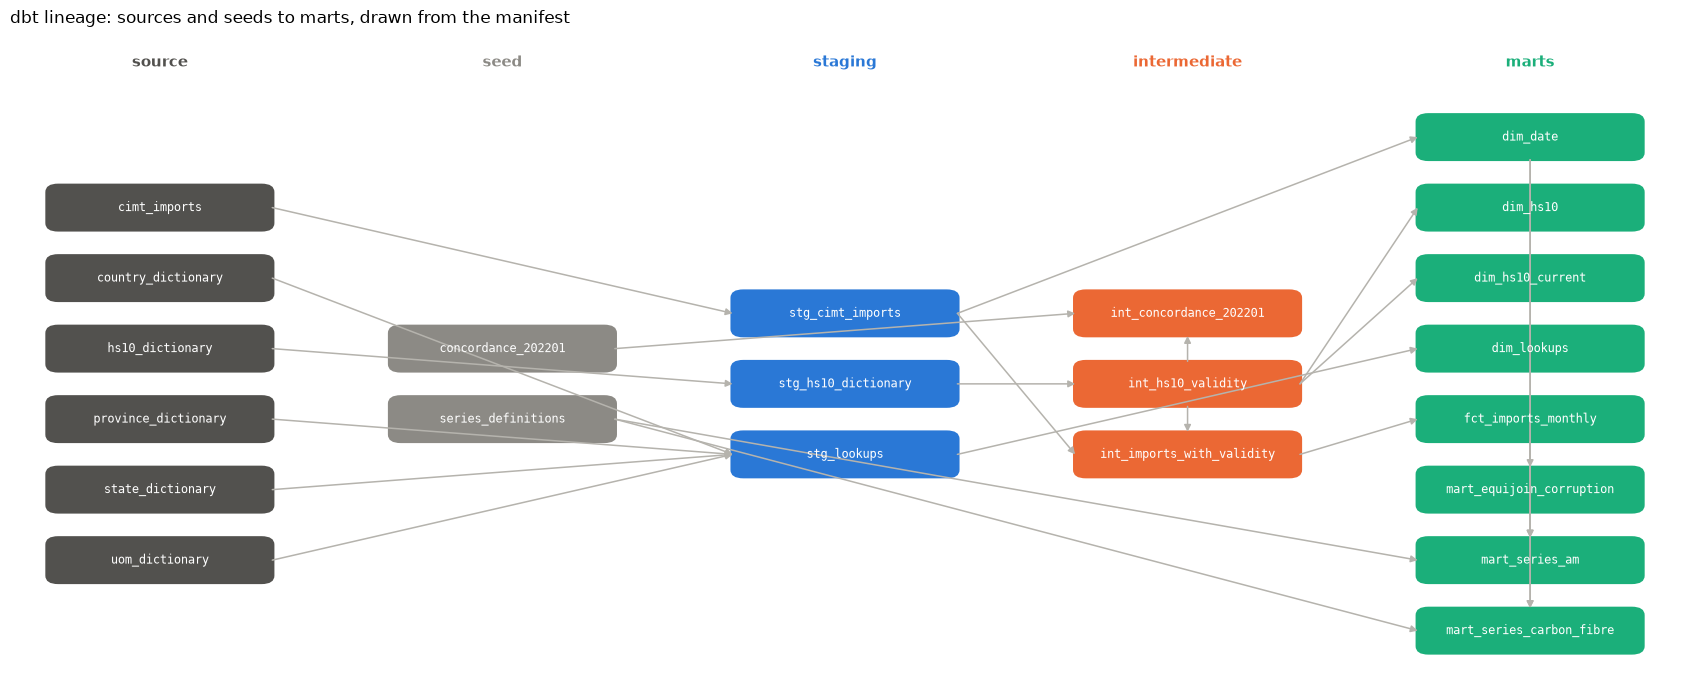

22 nodes drawn; docs at dbt/target/index.html, served with: dbt docs serve --project-dir dbt --profiles-dir dbt


In [66]:
# dbt's documentation site and the lineage picture for the README. dbt docs generate writes the
# catalogue and the manifest under dbt/target; the manifest carries every model's parents, and
# that is enough to draw the graph here rather than screenshot it, so the picture is reproducible
# and matches the code at the moment it was built. Sources and the crosswalk seeds on the
# left, then staging, intermediate and marts, one colour per layer, tests left out.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
dbt_docs = run_dbt("docs", "generate", show=6)
dbt_manifest = json.loads(Path("dbt/target/manifest.json").read_text(encoding="utf-8"))
nodes = {}
for unique_id, node in dbt_manifest["sources"].items():
    nodes[unique_id] = ("source", node["name"])
for unique_id, node in dbt_manifest["nodes"].items():
    if node["resource_type"] == "seed":
        nodes[unique_id] = ("seed", node["name"])
    if node["resource_type"] == "model":
        layer = "staging" if node["name"].startswith("stg_") else "intermediate" if node["name"].startswith("int_") else "marts"
        nodes[unique_id] = (layer, node["name"])
layers = ["source", "seed", "staging", "intermediate", "marts"]
palette = {"source": "#52514e", "seed": "#8c8a85", "staging": "#2a78d6", "intermediate": "#eb6834", "marts": "#1baf7a"}
positions = {}
for x, layer in enumerate(layers):
    members = sorted(uid for uid, (lyr, _) in nodes.items() if lyr == layer)
    for y, uid in enumerate(members):
        positions[uid] = (x * 3.2, -(y - (len(members) - 1) / 2) * 1.0)
fig, ax = plt.subplots(figsize=(17, 7))
for child, parents in dbt_manifest["parent_map"].items():
    if child not in positions:
        continue
    for parent in parents:
        if parent in positions:
            (x0, y0), (x1, y1) = positions[parent], positions[child]
            if x0 == x1:
                start, end = ((x0, y0 - 0.32), (x1, y1 + 0.32)) if y1 < y0 else ((x0, y0 + 0.32), (x1, y1 - 0.32))
            else:
                start, end = (x0 + 1.05, y0), (x1 - 1.05, y1)
            ax.annotate("", xy=end, xytext=start,
                        arrowprops={"arrowstyle": "-|>", "color": "#b5b3ad", "lw": 1.1, "shrinkA": 0, "shrinkB": 0})
for uid, (x, y) in positions.items():
    layer, name = nodes[uid]
    ax.add_patch(FancyBboxPatch((x - 1.05, y - 0.32), 2.1, 0.64, boxstyle="round,pad=0.02,rounding_size=0.12",
                                facecolor=palette[layer], edgecolor="none"))
    ax.text(x, y, name, ha="center", va="center", fontsize=8.5, color="white", family="monospace")
for x, layer in enumerate(layers):
    ax.text(x * 3.2, max(p[1] for p in positions.values()) + 0.95, layer, ha="center", va="bottom", fontsize=11, color=palette[layer], weight="bold")
ax.set_xlim(-1.4, (len(layers) - 1) * 3.2 + 1.4)
ax.set_ylim(min(p[1] for p in positions.values()) - 0.7, max(p[1] for p in positions.values()) + 1.5)
ax.axis("off")
ax.set_title("dbt lineage: sources and seeds to marts, drawn from the manifest", loc="left", fontsize=12)
plt.tight_layout()
plt.savefig("dbt/lineage.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"{len(nodes)} nodes drawn; docs at dbt/target/index.html, served with: dbt docs serve --project-dir dbt --profiles-dir dbt")


In [67]:
# The reclassification this project is built around is one date in the dictionary, so before any
# concordance is drawn I want to see what the dictionary itself says happened at that date: how many
# codes ended in December 2021, how many began in January 2022, how many of those are the same code
# carrying on with a new description, and how many were retired or created outright. Then the test
# that matters here. The rule I had planned pairs a retired code with the new codes in its own
# subheading, or failing that its heading, and the heading that received the 3D printers had no live
# code at all in 2021, so that rule cannot find a single predecessor for any of the nine codes.
break_counts = con.execute("""
    WITH ending AS (SELECT hs10, desc_en FROM int_hs10_validity WHERE valid_to = DATE '2021-12-31'),
         starting AS (SELECT hs10, desc_en FROM int_hs10_validity WHERE valid_from = DATE '2022-01-01')
    SELECT (SELECT COUNT(*) FROM ending)                                                              AS codes_ending_202112,
           (SELECT COUNT(*) FROM starting)                                                            AS codes_starting_202201,
           (SELECT COUNT(*) FROM ending e JOIN starting s USING (hs10))                               AS same_code_continues,
           (SELECT COUNT(*) FROM ending e JOIN starting s USING (hs10) WHERE e.desc_en <> s.desc_en)  AS same_code_new_description,
           (SELECT COUNT(*) FROM ending WHERE hs10 NOT IN (SELECT hs10 FROM starting))                AS codes_retired,
           (SELECT COUNT(*) FROM starting WHERE hs10 NOT IN (SELECT hs10 FROM ending))                AS codes_created
""").fetchdf()
print(break_counts.to_string(index=False))
rule_reach = con.execute("""
    WITH retired AS (SELECT hs10, hs6, hs4 FROM int_hs10_validity WHERE valid_to = DATE '2021-12-31'
                     AND hs10 NOT IN (SELECT hs10 FROM int_hs10_validity WHERE valid_from = DATE '2022-01-01')),
         created AS (SELECT hs10, hs6, hs4 FROM int_hs10_validity WHERE valid_from = DATE '2022-01-01'),
         reach AS (SELECT r.hs10,
                          (SELECT COUNT(*) FROM created c WHERE c.hs6 = r.hs6) AS in_subheading,
                          (SELECT COUNT(*) FROM created c WHERE c.hs4 = r.hs4) AS in_heading
                   FROM retired r)
    SELECT CASE WHEN in_subheading > 0 THEN 'new codes in the same subheading'
                WHEN in_heading > 0    THEN 'new codes only in the same heading'
                ELSE 'nothing new in the heading' END                                 AS what_the_rule_finds,
           COUNT(*)                                                                    AS retired_codes,
           SUM(CASE WHEN in_subheading > 0 THEN in_subheading ELSE in_heading END)     AS candidate_pairs
    FROM reach GROUP BY 1 ORDER BY 2 DESC
""").fetchdf()
print(chr(10) + "the subheading-then-heading rule, applied to the retired codes:")
print(rule_reach.to_string(index=False))
live_8485 = con.execute("SELECT COUNT(*) FROM int_hs10_validity WHERE hs4 = '8485' AND DATE '2021-12-01' BETWEEN valid_from AND valid_to").fetchone()[0]
print(chr(10) + f"codes live under heading 8485 in December 2021: {live_8485}; the rule has nothing to pair the nine new codes with")


 codes_ending_202112  codes_starting_202201  same_code_continues  same_code_new_description  codes_retired  codes_created
                 852                   1355                  424                        332            428            931

the subheading-then-heading rule, applied to the retired codes:
               what_the_rule_finds  retired_codes  candidate_pairs
new codes only in the same heading            284           3411.0
  new codes in the same subheading            134           1727.0
        nothing new in the heading             10              0.0

codes live under heading 8485 in December 2021: 0; the rule has nothing to pair the nine new codes with


In [68]:
# The dictionary cannot say where the goods under a retired code went, and the subheading rule has
# nothing to offer for the one heading I care about, so I go to the publisher. Statistics Canada
# prepared a ten-digit statistical concordance for the January 2022 tariff, published by the border
# agency as two spreadsheets: the original, and the 2022-1 amendment that carries chapters 27, 39,
# 42, 44, 63, 72, 73 and 85. This pulls both, keeps them under the data folder, reads the
# obsolete-to-new sheet of each, and writes the pairs as one committed CSV with the source file, its
# hash and the pull date on every row. That CSV is a dbt seed: the concordance model reads it, and it
# can be reviewed and corrected as a file rather than as code.
CONCORDANCE = DATA / "concordance"
CONCORDANCE.mkdir(exist_ok=True)
Path("crosswalks").mkdir(exist_ok=True)
CONC_BASE = "https://www.cbsa-asfc.gc.ca/trade-commerce/tariff-tarif/2022/concordance/"
CONC_FILES = ["conc-10-stats-2022.xlsx", "conc-10-stats-2022-1.xlsx"]
pairs = []
for name in CONC_FILES:
    target = CONCORDANCE / name
    if not target.exists():
        reply = requests.get(CONC_BASE + name, headers=HDRS, timeout=TIMEOUT)
        reply.raise_for_status()
        if "spreadsheet" not in (reply.headers.get("content-type") or ""):
            raise ValueError(f"{name}: expected a spreadsheet, got {reply.headers.get('content-type')}")
        target.write_bytes(reply.content)
    sheet = pd.read_excel(target, sheet_name="Obsolete to New", header=None, dtype=str, skiprows=1).iloc[:, [0, 2]]
    sheet.columns = ["obsolete_hs10", "new_hs10"]
    for col in sheet.columns:
        sheet[col] = sheet[col].str.replace(".", "", regex=False).str.strip()
    malformed = sheet[(sheet["obsolete_hs10"].str.len() != 10) | (sheet["new_hs10"].str.len() != 10)]
    if len(malformed):
        raise ValueError(f"{name}: {len(malformed)} rows are not ten-digit pairs")
    sheet["source_file"] = name
    sheet["source_url"] = CONC_BASE + name
    sheet["source_sha256"] = hashlib.sha256(target.read_bytes()).hexdigest()[:16]
    sheet["checked_on"] = datetime.fromtimestamp(target.stat().st_mtime, timezone.utc).date().isoformat()
    pairs.append(sheet)
    print(f"{name}: {len(sheet):,} pairs, {sheet['obsolete_hs10'].nunique():,} obsolete codes, {sheet['new_hs10'].nunique():,} new codes, "
          f"{(sheet['obsolete_hs10'] == sheet['new_hs10']).sum():,} pairs where the code is unchanged, {target.stat().st_size:,} bytes, pulled {sheet['checked_on'].iloc[0]}")
concordance_seed = pd.concat(pairs, ignore_index=True).drop_duplicates(subset=["obsolete_hs10", "new_hs10"])
concordance_seed.to_csv("crosswalks/concordance_202201.csv", index=False)
print(f"wrote crosswalks/concordance_202201.csv: {len(concordance_seed):,} distinct pairs across both files")


conc-10-stats-2022.xlsx: 2,052 pairs, 744 obsolete codes, 987 new codes, 405 pairs where the code is unchanged, 69,876 bytes, pulled 2026-09-07
conc-10-stats-2022-1.xlsx: 455 pairs, 108 obsolete codes, 368 new codes, 19 pairs where the code is unchanged, 28,530 bytes, pulled 2026-09-07
wrote crosswalks/concordance_202201.csv: 2,507 distinct pairs across both files


In [69]:
# Which codes make up each series is a judgement, so it goes into a committed CSV that the marts
# read as a seed, not into SQL. Three things are defined here. The recipients: the nine codes the
# dictionary opened under heading 8485 in January 2022. The donors: every 2021 code the publisher's
# concordance points at one of those nine, each taken over its unbroken run of periods through the
# break, because the goods that moved were inside these codes before 2022 and their narrowing is
# what the statistics will measure. And carbon fibre, whose windows and labels come straight from
# the dictionary rows read earlier: no code of its own before 1998, one clean code for three and a
# half years, the same code commingled with refractory brick for thirteen years, no code of its own
# again from October 2014, then three codes from 2022, with the epoxide sheet code that ended in 2011
# kept as its own short series. Every row carries the rule, a confidence and the source.
checked = datetime.now(timezone.utc).date().isoformat()
DICT_SOURCE = probe_entry["url"]
CONC_SOURCE = CONC_BASE + CONC_FILES[0]
unbroken_runs = con.execute("""
    WITH runs AS (
        SELECT hs10, valid_from, valid_to, desc_en,
               SUM(CASE WHEN prior_valid_to IS NULL OR valid_from <> prior_valid_to + 1 THEN 1 ELSE 0 END)
                   OVER (PARTITION BY hs10 ORDER BY valid_from) AS run_no
        FROM int_hs10_validity),
    through_break AS (SELECT hs10, run_no FROM runs WHERE DATE '2022-01-01' BETWEEN valid_from AND valid_to)
    SELECT r.hs10, MIN(r.valid_from) AS window_from,
           MAX(CASE WHEN r.valid_to = DATE '2021-12-31' THEN r.desc_en END) AS desc_2021,
           MAX(CASE WHEN r.valid_from = DATE '2022-01-01' THEN r.desc_en END) AS desc_2022
    FROM runs r JOIN through_break t USING (hs10, run_no) GROUP BY r.hs10
""").fetchdf().set_index("hs10")
recipients = con.execute("SELECT hs10, desc_en FROM int_hs10_validity WHERE hs4 = '8485' AND valid_from = DATE '2022-01-01' ORDER BY hs10").fetchdf()
donor_map = pd.read_csv("crosswalks/concordance_202201.csv", dtype=str)
donor_map = donor_map[donor_map["new_hs10"].str.startswith("8485")].groupby("obsolete_hs10")["new_hs10"].agg(lambda s: " ".join(sorted(set(s))))
rows = []
for r in recipients.itertuples():
    rows.append({"series_key": "am_recipients", "role": "recipient", "hs10": r.hs10, "window_from": "2022-01-01", "window_to": "9999-12-31",
                 "regime": "am recipient, from 2022-01", "rule": "dictionary: code opened under heading 8485 in 2022-01", "confidence": "high",
                 "source_url": DICT_SOURCE, "checked_on": checked, "note": r.desc_en})
for hs10, targets in donor_map.items():
    run = unbroken_runs.loc[hs10]
    rows.append({"series_key": "am_donors", "role": "donor", "hs10": hs10, "window_from": pd.Timestamp(run["window_from"]).strftime("%Y-%m-%d"), "window_to": "9999-12-31",
                 "regime": "am donor, narrowed at 2022-01", "rule": "published concordance: obsolete code maps to " + targets, "confidence": "high",
                 "source_url": CONC_SOURCE, "checked_on": checked, "note": f"2021: {run['desc_2021']} | 2022: {run['desc_2022']}"})
carbon_fibre = [
    ("carbon_fibre_articles", "window", None, "1988-01-01", "1997-12-31", "not separately coded",
     "dictionary: no carbon fibre code under heading 6815 before 1998-01", "high", "6815101000 read as graphite blocks for railway wheel moulds until 1997-12"),
    ("carbon_fibre_articles", "carbon fibre", "6815101000", "1998-01-01", "2001-07-31", "clean code",
     "dictionary: 6815101000 reads Carbon fibres and filaments", "high", ""),
    ("carbon_fibre_articles", "carbon fibre", "6815101000", "2001-08-01", "2014-09-30", "commingled with refractory brick",
     "dictionary: 6815101000 reads Carbon fib & fi; Refrac brick, block, tile & sim f prod of metall coke/iron/steel", "high",
     "same code, two unrelated goods; no clean series exists for these months"),
    ("carbon_fibre_articles", "window", None, "2014-10-01", "2021-12-31", "not separately coded",
     "dictionary: 6815100000 covers all non-electrical articles of graphite or other carbon", "high",
     "the publisher's 2022 concordance sends the three carbon fibre codes back to 6815999000, articles of stone or other mineral substances nes"),
    ("carbon_fibre_articles", "carbon fibre", "6815110000", "2022-01-01", "9999-12-31", "split into three codes",
     "dictionary: Articles, of carbon fibres, for non-electrical use", "high", ""),
    ("carbon_fibre_articles", "carbon fibre", "6815120000", "2022-01-01", "9999-12-31", "split into three codes",
     "dictionary: Articles, of fabrics of carbon fibres, for non-electrical uses", "high", ""),
    ("carbon_fibre_articles", "carbon fibre", "6815130000", "2022-01-01", "9999-12-31", "split into three codes",
     "dictionary: Articles, of carbon fibres, o/t fabric, for non-electrical uses", "high", ""),
    ("carbon_fibre_epoxide_sheet", "carbon fibre sheet", "3921909014", "1988-01-01", "1997-12-31", "epoxide sheet with carbon fibres",
     "dictionary: Film & sheet etc, of epoxide resin reinforced with carbon fibres", "high", "predecessor of 3921909914 with the same wording"),
    ("carbon_fibre_epoxide_sheet", "carbon fibre sheet", "3921909914", "1998-01-01", "2011-12-31", "epoxide sheet with carbon fibres",
     "dictionary: Film and sheet, etc, of epoxide resin reinforced with carbon fibres", "high", "ended 2011-12; no dedicated code since"),
    ("carbon_fibre_epoxide_sheet", "window", None, "2012-01-01", "9999-12-31", "not separately coded",
     "dictionary: from 2012-01 the sheet falls in a code shared with glass fibre, from 2014-10 in plastics nes", "high", ""),
]
for series_key, role, hs10, window_from, window_to, regime, rule, confidence, note in carbon_fibre:
    rows.append({"series_key": series_key, "role": role, "hs10": hs10, "window_from": window_from, "window_to": window_to, "regime": regime,
                 "rule": rule, "confidence": confidence, "source_url": DICT_SOURCE, "checked_on": checked, "note": note})
series_definitions = pd.DataFrame(rows)
series_definitions.to_csv("crosswalks/series_definitions.csv", index=False)
print(f"wrote crosswalks/series_definitions.csv: {len(series_definitions)} rows; "
      f"{(series_definitions['role'] == 'recipient').sum()} recipients, {(series_definitions['role'] == 'donor').sum()} donors, "
      f"{series_definitions['series_key'].str.startswith('carbon').sum()} carbon fibre rows")
print(series_definitions[["series_key", "role", "hs10", "window_from", "window_to", "regime"]].to_string(index=False))


wrote crosswalks/series_definitions.csv: 36 rows; 9 recipients, 17 donors, 10 carbon fibre rows
                series_key               role       hs10 window_from  window_to                           regime
             am_recipients          recipient 8485100000  2022-01-01 9999-12-31       am recipient, from 2022-01
             am_recipients          recipient 8485200000  2022-01-01 9999-12-31       am recipient, from 2022-01
             am_recipients          recipient 8485300000  2022-01-01 9999-12-31       am recipient, from 2022-01
             am_recipients          recipient 8485800000  2022-01-01 9999-12-31       am recipient, from 2022-01
             am_recipients          recipient 8485901000  2022-01-01 9999-12-31       am recipient, from 2022-01
             am_recipients          recipient 8485902000  2022-01-01 9999-12-31       am recipient, from 2022-01
             am_recipients          recipient 8485903000  2022-01-01 9999-12-31       am recipient, from 2022-01


In [70]:
# The seeds and the three models that read them, built with their tests. Selecting by name keeps
# the fact table out of this run: it has not changed, and its tests took the better part of a
# minute. Two singular tests matter here. Every code the dictionary ends in 2021-12 or starts in
# 2022-01 must appear in the published concordance, and every code in the series definitions must
# exist in the dictionary across the window claimed for it, with no carbon fibre window spanning a
# change of description.
dbt_series = run_dbt("build", "--select", "resource_type:seed", "int_concordance_202201", "mart_series_am", "mart_series_carbon_fibre", show=40)


2 of 30 OK loaded seed file main.series_definitions ............................ [INSERT 36 in 0.11s]
1 of 30 OK loaded seed file main.concordance_202201 ............................ [INSERT 2507 in 0.19s]
3 of 30 PASS accepted_values_series_definitions_role__recipient__donor__carbon_fibre__carbon_fibre_sheet__window  [PASS in 0.09s]
4 of 30 PASS accepted_values_series_definitions_series_key__am_recipients__am_donors__carbon_fibre_articles__carbon_fibre_epoxide_sheet  [PASS in 0.15s]
6 of 30 PASS not_null_series_definitions_regime ................................ [PASS in 0.06s]
5 of 30 PASS assert_series_codes_in_dictionary ................................. [PASS in 0.09s]
7 of 30 PASS not_null_series_definitions_role .................................. [PASS in 0.07s]
8 of 30 PASS not_null_series_definitions_series_key ............................ [PASS in 0.07s]
9 of 30 PASS not_null_series_definitions_window_from ........................... [PASS in 0.07s]
10 of 30 PASS not_null_ser

In [71]:
# The concordance as a table I can defend. First what kind of mapping the publisher drew: how many
# pairs are one to one, splits, merges or many to many. Then the check on the rule I nearly used:
# for the pairs where the code changed, how often the new code sits in the old code's subheading,
# its heading, its chapter, or another chapter altogether. Then the rows this project is about, the
# donors the publisher names for the nine 8485 codes and the codes it names for the 2022 carbon
# fibre split, and the full table with descriptions written out for review.
conc = con.execute("SELECT * FROM int_concordance_202201 ORDER BY new_hs10, obsolete_hs10").fetchdf()
print(f"{len(conc):,} pairs; {conc['obsolete_hs10'].nunique():,} obsolete codes; {conc['new_hs10'].nunique():,} new codes; "
      f"obsolete codes not ending 2021-12: {(~conc['obsolete_ends_2021_12']).sum()}; new codes not starting 2022-01: {(~conc['new_starts_2022_01']).sum()}")
print(conc.groupby("mapping_type").size().rename("pairs").sort_values(ascending=False).to_string())
changed = conc[~conc["same_code"]]
print(chr(10) + f"where the code changed ({len(changed):,} pairs), where the new code sits relative to the old one:")
print(changed.groupby("mechanical_relation").size().rename("pairs").sort_values(ascending=False).to_string())
in_reach = changed["mechanical_relation"].isin(["same subheading", "same heading"]).sum()
print(f"the subheading-then-heading rule would have reached {in_reach:,} of {len(changed):,} changed pairs and missed {len(changed) - in_reach:,}")
am_pairs = conc[conc["new_hs10"].str.startswith("8485")]
print(chr(10) + f"the publisher's donors for heading 8485: {am_pairs['obsolete_hs10'].nunique()} codes feeding {am_pairs['new_hs10'].nunique()} recipients")
print(am_pairs[["obsolete_hs10", "obsolete_desc_en", "new_hs10", "new_desc_en", "mechanical_relation"]].to_string(index=False))
cf_pairs = conc[conc["new_hs10"].isin(["6815110000", "6815120000", "6815130000", "6815190000"])]
print(chr(10) + "and for the 2022 carbon fibre codes:")
print(cf_pairs[["obsolete_hs10", "obsolete_desc_en", "new_hs10", "new_desc_en"]].to_string(index=False))
review_columns = ["obsolete_hs10", "obsolete_desc_en", "new_hs10", "new_desc_en", "same_code", "mechanical_relation", "mapping_type", "source_file", "checked_on"]
conc[review_columns].to_csv("crosswalks/concordance_202201_with_descriptions.csv", index=False)
print(chr(10) + "written for review: crosswalks/concordance_202201_with_descriptions.csv")


2,507 pairs; 852 obsolete codes; 1,355 new codes; obsolete codes not ending 2021-12: 0; new codes not starting 2022-01: 0
mapping_type
many to many    1319
split            906
one to one       170
merge            112

where the code changed (2,083 pairs), where the new code sits relative to the old one:
mechanical_relation
same heading         744
different chapter    598
same subheading      463
same chapter         278
the subheading-then-heading rule would have reached 1,207 of 2,083 changed pairs and missed 876

the publisher's donors for heading 8485: 17 codes feeding 9 recipients
obsolete_hs10                                                                  obsolete_desc_en   new_hs10                                                                      new_desc_en mechanical_relation
   8463900000        Machine-tools for working metal or cermets, without removing material, nes 8485100000               Machines, for additive manufacturing/3D printing, by metal deposit        sa

In [72]:
# The series the statistics will run on, read back by year so their shape is visible before any
# test is fitted: the recipient basket from 2022, the donor basket across the break, and the two
# together, the basket that does not change composition when the heading opens. Then each donor's
# value in 2021 against 2022, the raw form of the level shift the donors should show if the goods
# really moved, and the recipient basket's composition in the latest full year.
am = con.execute("SELECT series_key, series_group, role, hs10, ref_month, value_cad FROM mart_series_am").fetchdf()
am["year"] = am["ref_month"].dt.year
baskets = am[am["series_group"] == "basket"].pivot_table(index="series_key", columns="year", values="value_cad", aggfunc="sum") / 1e6
last_month = am["ref_month"].max()
print(f"baskets, CAD millions by year, months through {last_month:%Y-%m}" + (", so the last year is partial:" if last_month.month != 12 else ":"))
print(baskets.loc[["recipients", "donors", "combined"], 2019:].round(1).to_string())
donor_years = am[(am["series_group"] == "code") & (am["role"] == "donor")].pivot_table(index="hs10", columns="year", values="value_cad", aggfunc="sum") / 1e6
donor_years = donor_years.loc[:, 2020:2023]
donor_years["change_2021_to_2022"] = donor_years[2022] - donor_years[2021]
print(chr(10) + "donor codes, CAD millions:")
print(donor_years.round(1).sort_values("change_2021_to_2022").to_string())
full_years = am[am["role"] == "recipient"].groupby("year")["ref_month"].nunique()
latest_full = int(full_years[full_years == 12].index.max())
mix = am[(am["series_group"] == "code") & (am["role"] == "recipient") & (am["year"] == latest_full)].groupby("hs10")["value_cad"].sum().sort_values(ascending=False) / 1e6
print(chr(10) + f"recipient codes in {latest_full}, CAD millions and share:")
print(pd.DataFrame({"value_musd": mix.round(2), "share_pct": (100 * mix / mix.sum()).round(1)}).to_string())


baskets, CAD millions by year, months through 2026-07, so the last year is partial:
year          2019    2020    2021    2022    2023    2024    2025    2026
series_key                                                                
recipients     NaN     NaN     NaN    49.5    61.0    97.8   116.1    96.7
donors      2105.0  2053.0  2266.0  2401.0  2590.5  2937.1  3238.8  1975.7
combined    2105.0  2053.0  2266.0  2450.5  2651.5  3034.9  3355.0  2072.4

donor codes, CAD millions:
year         2020   2021    2022    2023  change_2021_to_2022
hs10                                                         
8477800000  107.0  100.3    86.6    99.0                -13.7
8477909090  107.3  124.1   114.8   126.2                 -9.3
8477903000   17.6   17.8     9.3     6.4                 -8.5
8466949000  134.4  125.7   119.8   125.7                 -5.9
8465990090   23.3   32.1    27.0    38.0                 -5.1
8477902090    3.1    3.9     4.9     3.4                  1.0
8463900000   22.2

In [73]:
# Carbon fibre by regime, read back from the mart: for each series and regime the months covered,
# the codes carrying it, the total and the average month. This is the table the chart is drawn from,
# and the reason no growth rate will be quoted across a regime boundary: the same code meant two
# different baskets before and after August 2001, and for two long stretches there is no code at all.
cf_regimes = con.execute("""
    SELECT series_key, regime, MIN(ref_month) AS first_month, MAX(ref_month) AS last_month, COUNT(*) AS months,
           MAX(n_codes) AS codes, ROUND(SUM(value_cad) / 1e6, 1) AS value_musd, ROUND(AVG(value_cad) / 1e6, 2) AS avg_month_musd
    FROM mart_series_carbon_fibre GROUP BY series_key, regime, regime_from ORDER BY 1, 3
""").fetchdf()
print(cf_regimes.to_string(index=False))


                series_key                           regime first_month last_month  months  codes  value_musd  avg_month_musd
     carbon_fibre_articles             not separately coded  1988-01-01 1997-12-01     120      0         NaN             NaN
     carbon_fibre_articles                       clean code  1998-01-01 2001-07-01      43      1        34.8            0.81
     carbon_fibre_articles commingled with refractory brick  2001-08-01 2014-09-01     158      1       216.2            1.37
     carbon_fibre_articles             not separately coded  2014-10-01 2021-12-01      87      0         NaN             NaN
     carbon_fibre_articles           split into three codes  2022-01-01 2026-07-01      55      3       228.4            4.15
carbon_fibre_epoxide_sheet epoxide sheet with carbon fibres  1988-01-01 1997-12-01     120      1         5.3            0.04
carbon_fibre_epoxide_sheet epoxide sheet with carbon fibres  1998-01-01 2011-12-01     168      1        10.9         

In [74]:
# The statistics run on one frame built here from the series mart: log monthly value for the donor
# basket, the combined basket and each donor code from January 2019, the first month all seventeen
# donors exist, to the last month in the data, and the recipients from January 2022. The design
# every test shares is a constant, a linear trend and eleven month dummies; the break models add a
# level shift from January 2022 and a change of slope from the same month. Logs need positive
# values, so any code series with a zero month in the window is set aside here and named, rather
# than patched with a small constant.
import statsmodels.api as sm
from scipy import stats
BREAK = pd.Timestamp("2022-01-01")
WINDOW_FROM = pd.Timestamp("2019-01-01")
am_all = con.execute("SELECT series_key, series_group, role, hs10, ref_month, value_cad FROM mart_series_am ORDER BY series_key, ref_month").fetchdf()
am_all["ref_month"] = pd.to_datetime(am_all["ref_month"])
LAST_MONTH = am_all["ref_month"].max()

def series(key, start=WINDOW_FROM):
    s = am_all[am_all["series_key"] == key].set_index("ref_month")["value_cad"].sort_index()
    return s[s.index >= start]

def design(idx, with_break=True):
    t = np.arange(len(idx), dtype=float)
    X = pd.DataFrame({"const": 1.0, "trend": t}, index=idx)
    for m in range(2, 13):
        X[f"m{m:02d}"] = (idx.month == m).astype(float)
    if with_break:
        post = (idx >= BREAK).astype(float)
        X["post"] = post
        X["post_trend"] = post * (t - float(idx.get_indexer([BREAK])[0]))
    return X

donor_keys = sorted(k for k in am_all.loc[am_all["role"] == "donor", "series_key"].unique() if k.startswith("donor:"))
usable, set_aside = [], []
for key in donor_keys:
    zeros = int((series(key) == 0).sum())
    (set_aside if zeros else usable).append((key, zeros))
months_pre = int((series("donors").index < BREAK).sum())
months_post = int((series("donors").index >= BREAK).sum())
print(f"window {WINDOW_FROM:%Y-%m} to {LAST_MONTH:%Y-%m}: {months_pre} months before the break, {months_post} after")
print(f"design: constant, trend, 11 month dummies; the break models add a level shift and a slope change at {BREAK:%Y-%m}")
print(f"donor codes with a full positive history: {len(usable)}; set aside for zero months: " + (", ".join(f"{k} ({z} zero months)" for k, z in set_aside) or "none"))


window 2019-01 to 2026-07: 36 months before the break, 55 after
design: constant, trend, 11 month dummies; the break models add a level shift and a slope change at 2022-01
donor codes with a full positive history: 16; set aside for zero months: donor:8479893000 (12 zero months)


In [75]:
# The Chow test at the known break, January 2022. One regression over the whole window against
# two fitted separately before and after, every coefficient free to change, so the F statistic
# asks whether one line with one seasonal pattern describes both halves. Run on the donor basket,
# the combined basket and each donor code with a full history. The direction of any shift comes
# from the fit itself: the mean of the post-break residuals from the pre-break fit, in log points.
def chow_test(y, break_at):
    X = design(y.index, with_break=False)
    pre = y.index < break_at
    k, n = X.shape[1], len(y)
    def rss(yy, XX):
        beta = np.linalg.lstsq(XX, yy, rcond=None)[0]
        return float(((yy - XX @ beta) ** 2).sum()), beta
    rss_all, _ = rss(y.values, X.values)
    rss_pre, beta_pre = rss(y.values[pre], X.values[pre])
    rss_post, _ = rss(y.values[~pre], X.values[~pre])
    f_stat = ((rss_all - rss_pre - rss_post) / k) / ((rss_pre + rss_post) / (n - 2 * k))
    post_shift = float((y.values[~pre] - X.values[~pre] @ beta_pre).mean())
    return f_stat, float(stats.f.sf(f_stat, k, n - 2 * k)), k, n, post_shift

chow_rows = []
for key in ["donors", "combined"] + [k for k, _ in usable]:
    f_stat, p_value, k, n, post_shift = chow_test(np.log(series(key)), BREAK)
    chow_rows.append({"series": key, "F": round(f_stat, 2), "p_value": round(p_value, 4), "df": f"{k}, {n - 2 * k}",
                      "post_shift_log": round(post_shift, 3), "post_shift_pct": round(100 * (np.exp(post_shift) - 1), 1)})
chow_at_break = pd.DataFrame(chow_rows)
print(chow_at_break.to_string(index=False))
print(chr(10) + "series with p below 0.05: " + (", ".join(chow_at_break.loc[chow_at_break["p_value"] < 0.05, "series"]) or "none"))


          series    F  p_value     df  post_shift_log  post_shift_pct
          donors 1.46   0.1575 13, 65           0.145            15.5
        combined 1.59   0.1100 13, 65           0.175            19.1
donor:8441800000 1.87   0.0502 13, 65           0.316            37.2
donor:8463900000 0.79   0.6720 13, 65           0.867           138.0
donor:8465990019 1.01   0.4552 13, 65           0.719           105.1
donor:8465990090 0.39   0.9682 13, 65          -0.112           -10.6
donor:8466941000 0.80   0.6553 13, 65           0.673            96.1
donor:8466949000 1.47   0.1526 13, 65           0.154            16.6
donor:8475290000 1.48   0.1506 13, 65           1.568           379.8
donor:8475900000 2.90   0.0023 13, 65          -1.160           -68.6
donor:8477800000 1.22   0.2836 13, 65           0.094             9.8
donor:8477901000 1.14   0.3437 13, 65          -0.137           -12.8
donor:8477902090 0.75   0.7101 13, 65           0.592            80.8
donor:8477903000 2.7

In [76]:
# The scan for an unknown break: the same Chow statistic at every month that leaves at least
# eighteen months on each side, for the donor basket, the combined basket and the plastics donor
# 8477800000, the one code whose fall at the break was visible in the raw numbers. This is a rolling
# Chow scan and nothing more. The largest F locates the month the data most wants to split at; the
# ordinary F distribution does not apply to a maximum taken over many candidates, so no p-value is
# attached to it. What matters is whether January 2022 is that month, or near it.
def chow_scan(y, margin=18):
    rows = []
    for i in range(margin, len(y) - margin):
        f_stat, _, _, _, shift = chow_test(y, y.index[i])
        rows.append({"break_at": y.index[i], "F": f_stat, "post_shift_log": shift})
    return pd.DataFrame(rows).set_index("break_at")

scan_summary = []
for key in ["donors", "combined", "donor:8477800000"]:
    scan = chow_scan(np.log(series(key)))
    best = scan["F"].idxmax()
    at_break = scan.loc[BREAK, "F"]
    scan_summary.append({"series": key, "months_scanned": len(scan), "max_F_at": best.strftime("%Y-%m"), "max_F": round(scan["F"].max(), 2),
                         "F_at_2022_01": round(at_break, 2), "rank_of_2022_01": int((scan["F"] > at_break).sum()) + 1,
                         "shift_at_max_pct": round(100 * (np.exp(scan.loc[best, "post_shift_log"]) - 1), 1)})
    print(f"{key}: the five largest F")
    print(scan.sort_values("F", ascending=False).head(5).round(2).T.rename(columns=lambda d: d.strftime("%Y-%m")).to_string())
    print()
scan_table = pd.DataFrame(scan_summary)
print(scan_table.to_string(index=False))


donors: the five largest F
break_at        2025-01  2024-12  2024-11  2024-09  2020-10
F                  2.14     2.12     2.01     1.83     1.82
post_shift_log     0.06     0.07     0.08     0.09     0.24

combined: the five largest F
break_at        2020-09  2020-10  2020-08  2020-07  2020-11
F                  2.07     2.07     2.07     2.07     2.02
post_shift_log     0.30     0.27     0.28     0.24     0.36

donor:8477800000: the five largest F
break_at        2021-08  2021-09  2021-07  2021-10  2021-06
F                  2.08     2.06     1.98     1.98     1.93
post_shift_log    -0.44    -0.39    -0.32    -0.27    -0.32

          series  months_scanned max_F_at  max_F  F_at_2022_01  rank_of_2022_01  shift_at_max_pct
          donors              55  2025-01   2.14          1.46               26               5.8
        combined              55  2020-09   2.07          1.59               27              34.5
donor:8477800000              55  2021-08   2.08          1.22        

In [77]:
# The interrupted time series: log value on a trend, a level shift from January 2022, a change of
# slope from the same month and the month dummies, with Newey-West standard errors at four lags,
# the usual three quarters of the cube root of the sample rounded up. The level shift is the
# estimate of what left a donor at the break; applied to the donor's actual 2021 value it gives
# that amount in dollars, which is the backcast the bridged growth estimate needs. Run on the donor
# basket, the combined basket, which should show no shift if the goods only moved within it, and
# each donor code with a full history. The recipients have no pre-period, so for them the model is
# trend and season only and the number that matters is the trend.
HAC_LAGS = 4
def its_fit(key):
    y = np.log(series(key, WINDOW_FROM if key != "recipients" else BREAK))
    X = design(y.index, with_break=(key != "recipients"))
    return y, X, sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": HAC_LAGS})

its_rows, its_fits = [], {}
for key in ["donors", "combined"] + [k for k, _ in usable]:
    y, X, fit = its_fit(key)
    its_fits[key] = (y, X, fit)
    shift = fit.params["post"]
    its_rows.append({"series": key, "level_shift_log": round(shift, 4), "level_shift_pct": round(100 * (np.exp(shift) - 1), 1),
                     "se_hac": round(fit.bse["post"], 4), "p_value": round(fit.pvalues["post"], 3),
                     "slope_change_per_month": round(fit.params["post_trend"], 5), "slope_p_value": round(fit.pvalues["post_trend"], 3),
                     "moved_out_of_2021_cad_m": round((1 - np.exp(shift)) * series(key).loc["2021"].sum() / 1e6, 1)})
its_table = pd.DataFrame(its_rows)
print(its_table.to_string(index=False))
y, X, fit = its_fit("recipients")
its_fits["recipients"] = (y, X, fit)
print(chr(10) + f"recipients, trend and season only from {BREAK:%Y-%m}: trend {fit.params['trend']:+.4f} log per month (se {fit.bse['trend']:.4f}), "
      f"{100 * (np.exp(12 * fit.params['trend']) - 1):+.1f}% a year")
negative = its_table[(its_table["level_shift_log"] < 0) & (its_table["p_value"] < 0.05)]
print("series with a negative level shift at p below 0.05: " + (", ".join(negative["series"]) or "none"))


          series  level_shift_log  level_shift_pct  se_hac  p_value  slope_change_per_month  slope_p_value  moved_out_of_2021_cad_m
          donors           0.0160              1.6  0.0386    0.679                 0.00476          0.001                    -36.5
        combined           0.0310              3.1  0.0388    0.425                 0.00534          0.000                    -71.4
donor:8441800000           0.8534            134.8  0.3762    0.023                 0.00589          0.689                    -46.0
donor:8463900000           0.4043             49.8  0.2198    0.066                 0.01404          0.160                    -10.0
donor:8465990019           0.3958             48.6  0.2532    0.118                 0.00219          0.837                     -3.8
donor:8465990090           0.0870              9.1  0.1906    0.648                -0.00484          0.556                     -2.9
donor:8466941000           0.2371             26.8  0.3372    0.482         

In [78]:
# Three growth estimates from 2021, the last full year before the heading existed, to 2025, the
# last full year in the data. Published: the recipient codes have no 2021 value, so the growth a
# reader of the published series would compute is undefined, and the growth inside the published
# series from its first year is shown for what it is. Basket-invariant: the combined basket, whose
# contents do not change at the break, so its growth is the printers plus everything else the
# donors carry. Bridged: the recipients in 2025 against the 2021 level the donor level shift says
# the printers had before the break, done for the donor basket and for the one pair the raw numbers
# singled out, the plastics donor against the plastics printers. A bridged rate exists only when
# the shift is negative. Its uncertainty comes from a moving-block bootstrap of the interrupted
# time series residuals, six-month blocks, two thousand replicates, with the count of replicates
# that gave no negative shift reported beside the interval rather than dropped. The draws are
# kept, because the chart further down draws its band from the same replicates.
rng = np.random.default_rng(20220101)
BLOCK, REPS = 6, 2000
bridged_draws = {}
def bridged(donor_key, recipient_key):
    if donor_key not in its_fits:
        its_fits[donor_key] = its_fit(donor_key)
    y, X, fit = its_fits[donor_key]
    base_2021 = series(donor_key).loc["2021"].sum()
    target_2025 = series(recipient_key, BREAK).loc["2025"].sum()
    def rate(shift):
        back = (1 - np.exp(shift)) * base_2021
        return (target_2025 / back - 1) if back > 0 else np.nan
    point = rate(fit.params["post"])
    resid, fitted = fit.resid.values, fit.fittedvalues.values
    n, post_col = len(resid), list(X.columns).index("post")
    draws = []
    for _ in range(REPS):
        starts = rng.integers(0, n - BLOCK + 1, size=int(np.ceil(n / BLOCK)))
        shuffled = np.concatenate([resid[s:s + BLOCK] for s in starts])[:n]
        beta = np.linalg.lstsq(X.values, fitted + shuffled, rcond=None)[0]
        draws.append(rate(beta[post_col]))
    draws = np.array(draws)
    defined = draws[~np.isnan(draws)]
    bridged_draws[donor_key] = {"backcast_2021_cad": np.where(np.isnan(draws), np.nan, target_2025 / (1 + draws)), "growth": draws,
                                "point_backcast_2021_cad": (1 - np.exp(fit.params["post"])) * base_2021, "recipient_2025_cad": target_2025}
    return {"donor": donor_key, "recipient": recipient_key,
            "backcast_2021_cad_m": round((1 - np.exp(fit.params["post"])) * base_2021 / 1e6, 1), "recipient_2025_cad_m": round(target_2025 / 1e6, 1),
            "bridged_growth_pct": round(100 * point, 1) if not np.isnan(point) else np.nan,
            "ci_2_5_pct": round(100 * np.percentile(defined, 2.5), 1) if len(defined) else np.nan,
            "ci_97_5_pct": round(100 * np.percentile(defined, 97.5), 1) if len(defined) else np.nan,
            "replicates_undefined": int(np.isnan(draws).sum())}

rec, comb = series("recipients", BREAK), series("combined")
print(f"published: recipients 2021 = 0 by construction, growth to 2025 undefined; inside the published series, "
      f"2022 {rec.loc['2022'].sum() / 1e6:.1f}M to 2025 {rec.loc['2025'].sum() / 1e6:.1f}M is {100 * (rec.loc['2025'].sum() / rec.loc['2022'].sum() - 1):+.1f}%")
print(f"basket-invariant: combined 2021 {comb.loc['2021'].sum() / 1e6:.1f}M to 2025 {comb.loc['2025'].sum() / 1e6:.1f}M is "
      f"{100 * (comb.loc['2025'].sum() / comb.loc['2021'].sum() - 1):+.1f}%, printers and everything else the donors carry together")
growth_bridged = pd.DataFrame([bridged("donors", "recipients"), bridged("donor:8477800000", "recipient:8485200000")])
print(chr(10) + "bridged, with the block-bootstrap interval:")
print(growth_bridged.to_string(index=False))


published: recipients 2021 = 0 by construction, growth to 2025 undefined; inside the published series, 2022 49.5M to 2025 116.1M is +134.8%
basket-invariant: combined 2021 2266.0M to 2025 3355.0M is +48.1%, printers and everything else the donors carry together

bridged, with the block-bootstrap interval:
           donor            recipient  backcast_2021_cad_m  recipient_2025_cad_m  bridged_growth_pct  ci_2_5_pct  ci_97_5_pct  replicates_undefined
          donors           recipients                -36.5                 116.1                 NaN       -42.7       4343.9                  1266
donor:8477800000 recipient:8485200000                 26.0                  62.7               141.7        36.2       1463.0                    60


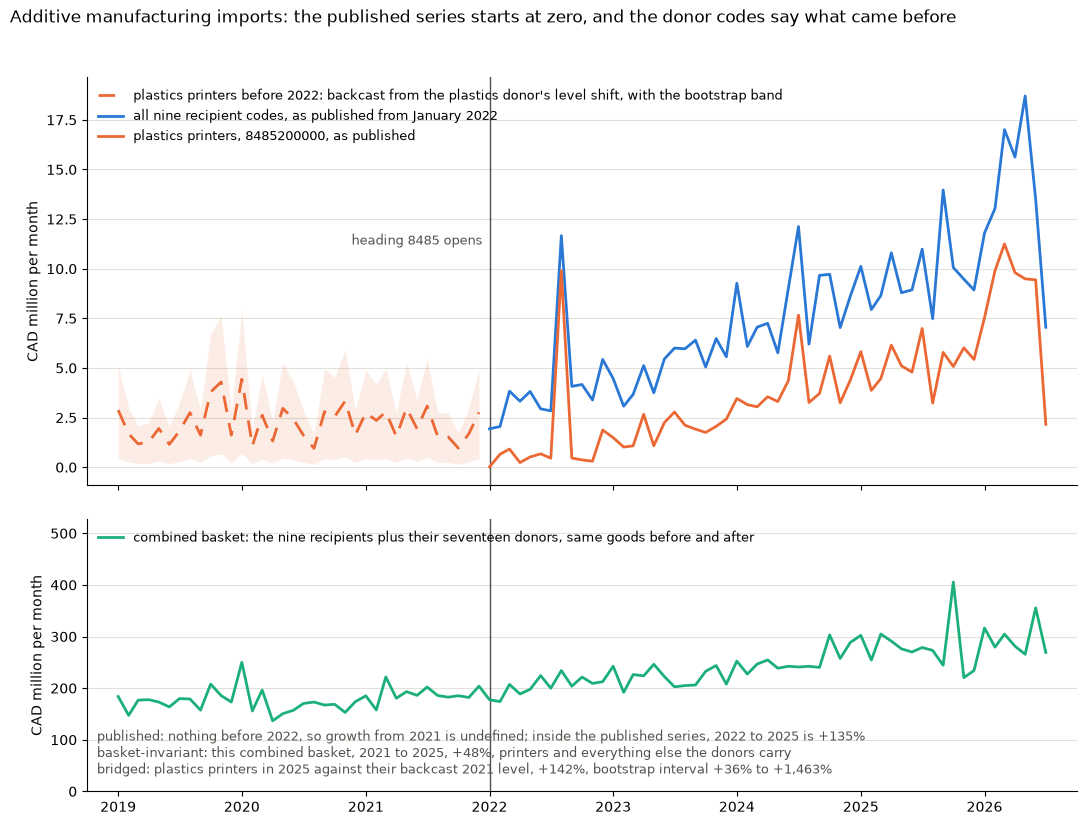

In [79]:
# The first chart: the recipient basket as published, the plastics printers with the level their
# donor gave up drawn back across the three years before the heading existed, and under it the
# combined basket that does not change composition at the break. Two panels on one time axis,
# each with its own scale, because the recipients are two percent of the combined basket and one
# axis would flatten them into the floor. The backcast is the donor's monthly value times the
# share the level shift removed, so it keeps the donor's own seasonality, and the band is that
# share across the bootstrap replicates that gave a negative shift. The three estimates are
# written on the chart, the undefined one included.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
BLUE, ORANGE, AQUA, INK, GRID = "#2a78d6", "#eb6834", "#1baf7a", "#52514e", "#e1e0d9"
plastics_donor, plastics_recipient = "donor:8477800000", "recipient:8485200000"
draws = bridged_draws[plastics_donor]
donor_all = series(plastics_donor)
donor_pre = donor_all[donor_all.index < BREAK]
base_2021 = donor_all.loc["2021"].sum()
share_point = draws["point_backcast_2021_cad"] / base_2021
share_draws = draws["backcast_2021_cad"][~np.isnan(draws["backcast_2021_cad"])] / base_2021
backcast = donor_pre * share_point
band_lo, band_hi = donor_pre * np.percentile(share_draws, 2.5), donor_pre * np.percentile(share_draws, 97.5)
recipients_m, plastics_m, combined_m = series("recipients", BREAK), series(plastics_recipient, BREAK), series("combined")
published_growth = 100 * (recipients_m.loc["2025"].sum() / recipients_m.loc["2022"].sum() - 1)
invariant_growth = 100 * (combined_m.loc["2025"].sum() / combined_m.loc["2021"].sum() - 1)
bridge = growth_bridged.set_index("donor").loc[plastics_donor]

fig, (top, bottom) = plt.subplots(2, 1, figsize=(11, 8.5), sharex=True, gridspec_kw={"height_ratios": [3, 2], "hspace": 0.1})
for ax in (top, bottom):
    ax.axvline(BREAK, color=INK, linewidth=1)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_ylabel("CAD million per month")
top.fill_between(band_lo.index, band_lo / 1e6, band_hi / 1e6, color=ORANGE, alpha=0.12, linewidth=0)
top.plot(backcast.index, backcast / 1e6, color=ORANGE, linewidth=2, linestyle=(0, (6, 4)),
         label="plastics printers before 2022: backcast from the plastics donor's level shift, with the bootstrap band")
top.plot(recipients_m.index, recipients_m / 1e6, color=BLUE, linewidth=2, label="all nine recipient codes, as published from January 2022")
top.plot(plastics_m.index, plastics_m / 1e6, color=ORANGE, linewidth=2, label="plastics printers, 8485200000, as published")
top.legend(frameon=False, loc="upper left", fontsize=9)
top.annotate("heading 8485 opens", xy=(BREAK, 0.6), xycoords=("data", "axes fraction"), xytext=(-5, 0), textcoords="offset points",
             ha="right", va="center", fontsize=9, color=INK)
top.set_xlim(WINDOW_FROM - pd.offsets.MonthBegin(3), LAST_MONTH + pd.offsets.MonthBegin(3))
bottom.plot(combined_m.index, combined_m / 1e6, color=AQUA, linewidth=2, label="combined basket: the nine recipients plus their seventeen donors, same goods before and after")
bottom.set_ylim(0, combined_m.max() / 1e6 * 1.3)
bottom.legend(frameon=False, loc="upper left", fontsize=9)
bottom.text(0.01, 0.05,
            f"published: nothing before 2022, so growth from 2021 is undefined; inside the published series, 2022 to 2025 is {published_growth:+.0f}%" + chr(10)
            + f"basket-invariant: this combined basket, 2021 to 2025, {invariant_growth:+.0f}%, printers and everything else the donors carry" + chr(10)
            + f"bridged: plastics printers in 2025 against their backcast 2021 level, {bridge['bridged_growth_pct']:+.0f}%, "
            + f"bootstrap interval {bridge['ci_2_5_pct']:+.0f}% to {bridge['ci_97_5_pct']:+,.0f}%",
            transform=bottom.transAxes, fontsize=9, color=INK, va="bottom", ha="left")
bottom.xaxis.set_major_locator(mdates.YearLocator())
bottom.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Additive manufacturing imports: the published series starts at zero, and the donor codes say what came before", x=0.01, ha="left", fontsize=12)
fig.subplots_adjust(left=0.08, right=0.98, top=0.9, bottom=0.06)
plt.savefig("am_imports_three_estimates.png", dpi=150, bbox_inches="tight")
plt.show()


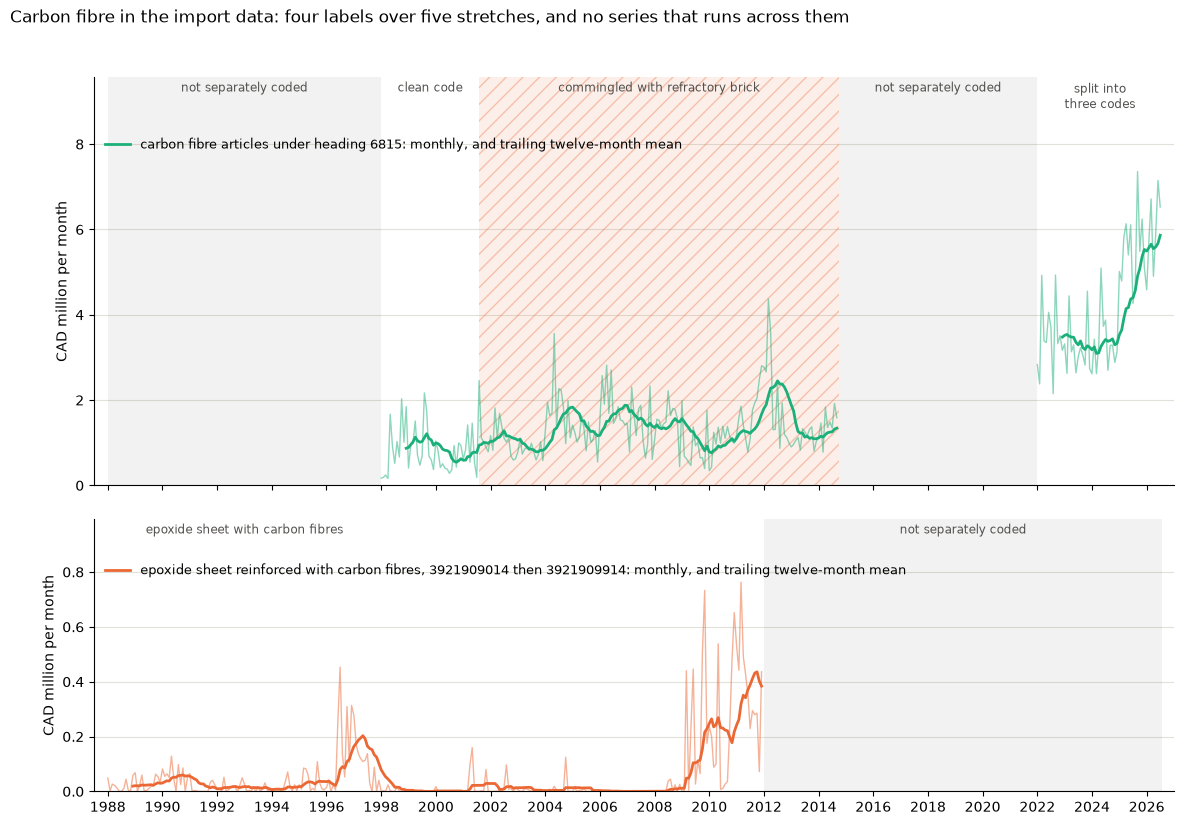

In [80]:
# The second chart: carbon fibre articles month by month from 1988 with the dictionary's regimes
# behind the line, and the epoxide sheet series on its own panel because it is a hundredth of
# the size. The bands say what the series is in each stretch: nothing of its own, one clean
# code, the same code shared with refractory brick, nothing of its own again, then three codes.
# The thin line is the month, the heavy one the trailing twelve-month mean. No growth is drawn
# or quoted across any of those edges.
import textwrap
cf_chart = con.execute("SELECT series_key, ref_month, regime, regime_from, value_cad FROM mart_series_carbon_fibre ORDER BY series_key, ref_month").fetchdf()
cf_chart["ref_month"] = pd.to_datetime(cf_chart["ref_month"])
cf_chart["regime_from"] = pd.to_datetime(cf_chart["regime_from"])
articles = cf_chart[cf_chart["series_key"] == "carbon_fibre_articles"].set_index("ref_month")
sheet = cf_chart[cf_chart["series_key"] == "carbon_fibre_epoxide_sheet"].set_index("ref_month")

fig, (top, bottom) = plt.subplots(2, 1, figsize=(12, 8.5), sharex=True, gridspec_kw={"height_ratios": [3, 2], "hspace": 0.1})
panels = ((top, articles, AQUA, "carbon fibre articles under heading 6815"),
          (bottom, sheet, ORANGE, "epoxide sheet reinforced with carbon fibres, 3921909014 then 3921909914"))
for ax, frame, colour, label in panels:
    windows = frame.reset_index().groupby(["regime_from", "regime"])["ref_month"].agg(["min", "max"]).reset_index().sort_values("regime_from")
    previous = None
    for w in windows.itertuples():
        end = w.max + pd.offsets.MonthEnd(0)
        if w.regime == "not separately coded":
            ax.axvspan(w.min, end, facecolor=INK, alpha=0.07, linewidth=0)
        elif w.regime == "commingled with refractory brick":
            ax.axvspan(w.min, end, facecolor=ORANGE, alpha=0.10, linewidth=0)
            ax.axvspan(w.min, end, facecolor="none", edgecolor=ORANGE, alpha=0.35, hatch="//", linewidth=0)
        if w.regime != previous:
            text = w.regime if (end - w.min).days > 6 * 365 else chr(10).join(textwrap.wrap(w.regime, 12))
            ax.annotate(text, xy=(w.min + (end - w.min) / 2, 1.0), xycoords=("data", "axes fraction"), xytext=(0, -3),
                        textcoords="offset points", ha="center", va="top", fontsize=8.5, color=INK)
        previous = w.regime
    monthly = frame["value_cad"] / 1e6
    ax.plot(monthly.index, monthly, color=colour, linewidth=1, alpha=0.5)
    ax.plot(monthly.index, monthly.rolling(12).mean(), color=colour, linewidth=2, label=label + ": monthly, and trailing twelve-month mean")
    ax.set_ylim(0, monthly.max() * 1.3)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_ylabel("CAD million per month")
    ax.legend(frameon=False, loc="upper left", fontsize=9, bbox_to_anchor=(0, 0.88))
bottom.set_xlim(cf_chart["ref_month"].min() - pd.offsets.MonthBegin(6), cf_chart["ref_month"].max() + pd.offsets.MonthBegin(6))
bottom.xaxis.set_major_locator(mdates.YearLocator(2))
bottom.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Carbon fibre in the import data: four labels over five stretches, and no series that runs across them", x=0.01, ha="left", fontsize=12)
fig.subplots_adjust(left=0.08, right=0.98, top=0.9, bottom=0.06)
plt.savefig("carbon_fibre_regimes.png", dpi=150, bbox_inches="tight")
plt.show()


In [81]:
# The star for the dashboard, written as CSVs under the ignored data folder. The fact at source
# grain is a hundred and eighty-six million rows and belongs in DuckDB, not in a workbook, so the
# dashboard gets two facts cut from it: every year, code, period and province, which is what the
# corruption measures and the province security role need, and the monthly series with their
# regime labels, which is what the time axis and the regime slicer need. The dimensions are the
# validity dimension itself, its naive counterpart, the month and year calendars, the province
# and partner lookups, and the series definitions. Row counts are read back from the files.
PBI = Path("../data/powerbi/additive_trade")
PBI.mkdir(parents=True, exist_ok=True)
exports = {
    "dim_hs10": "SELECT hs10_period_key, hs10, hs2, hs4, hs6, valid_from, valid_to, is_current, version_no, n_versions, uom, desc_en, desc_fr, meaning_changed, code_ever_changed_meaning, current_desc_en, differs_from_current FROM dim_hs10 ORDER BY hs10, valid_from",
    "dim_hs10_current": "SELECT hs10, hs2, hs4, hs6, current_desc_en, current_since, n_versions, code_ever_changed_meaning FROM dim_hs10_current ORDER BY hs10",
    "dim_date": "SELECT ref_month, year, month_no, month_name, quarter, year_month, from_2022 FROM dim_date ORDER BY ref_month",
    "dim_year": "SELECT DISTINCT year, MAKE_DATE(year, 1, 1) AS year_start, year >= 2022 AS from_2022 FROM dim_date ORDER BY year",
    "dim_province": "SELECT code AS province, code_number AS province_number, desc_en AS province_name, desc_fr AS province_name_fr, is_current FROM dim_lookups WHERE lookup = 'province' ORDER BY code",
    "dim_partner": "SELECT code AS partner_country, code_number AS partner_number, desc_en AS partner_name, desc_fr AS partner_name_fr, is_current FROM dim_lookups WHERE lookup = 'country' ORDER BY code",
    "dim_series": "SELECT series_key, role, hs10, window_from, window_to, regime, rule, confidence, source_url, checked_on, note FROM series_definitions ORDER BY series_key, window_from, hs10",
    "fct_imports_yearly_province": "SELECT year, hs10, hs10_period_key, equijoin_status, province, SUM(value_cad) AS value_cad, COUNT(*) AS source_rows FROM fct_imports_monthly GROUP BY 1, 2, 3, 4, 5 ORDER BY 1, 2, 5",
    "fct_series_monthly": "SELECT series_key, 'additive manufacturing' AS family, series_group, role, hs10, ref_month, NULL AS regime, value_cad FROM mart_series_am UNION ALL SELECT series_key, 'carbon fibre', 'series', 'carbon fibre', codes, ref_month, regime, value_cad FROM mart_series_carbon_fibre ORDER BY 1, 6",
}
star = []
for name, sql in exports.items():
    path = PBI / f"{name}.csv"
    con.execute(f"COPY ({sql}) TO '{path.as_posix()}' (HEADER, DELIMITER ',')")
    rows = con.execute(f"SELECT COUNT(*) FROM read_csv('{path.as_posix()}', header = true, all_varchar = true)").fetchone()[0]
    star.append({"table": name, "rows": rows, "mb": round(path.stat().st_size / 1e6, 1)})
star = pd.DataFrame(star)
print(star.to_string(index=False))
print(f"written to {PBI.resolve()}")


                      table    rows    mb
                   dim_hs10   53570  13.4
           dim_hs10_current   10930   1.2
                   dim_date     463   0.0
                   dim_year      39   0.0
               dim_province      14   0.0
                dim_partner     263   0.0
                 dim_series      36   0.0
fct_imports_yearly_province 3301776 197.1
         fct_series_monthly    5800   0.5
written to C:\Adyan\projects\data_analytics_portfolio\data\powerbi\additive_trade
